In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import itertools
import jinja2
import json
import logging
import scipy.stats

from IPython.display import HTML

logging.basicConfig(level=logging.INFO)

In [2]:
### Matplotlib settings

plt.rcParams["font.family"] = "Helvetica"
matplotlib.rc("font", size=11)
plt.ion()  # so plots show up immediately

In [3]:
from pathlib import Path

if Path.cwd().name == "notebooks":
    %cd ..
import value_aggregation as pm
from llm import model_experiment
from common.shared_analysis import *

# Analysing Data

In [4]:
## Variables
scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=3\
_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0"

random_scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101\
_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0"

scenario_file = os.path.join(SCENARIOS_DIR, scenario + ".csv")
random_scenario_file = os.path.join(SCENARIOS_DIR, random_scenario + ".csv")

mturk_condition = "chart_type=area_maximize=True"

model = "gpt-4"
llm_condition = "temp=1_api=chat_qualification=False_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv"

### For getting tcolorbox colors

In [5]:
[x * 256 for x in CONDITION_TO_COLOR["Volume"]]

[256.0, 217.85098039215686, 47.1843137254902, 256.0]

In [6]:
[x - 0.1 for x in CONDITION_TO_COLOR["Volume"]]

[0.9, 0.7509803921568627, 0.08431372549019608, 0.9]

### Figure utilities

### Qualificaiton Stats

In [7]:
total_correct = 0
total_size = 0
times = []
for file in os.listdir(MTURK_RESULTS_DIR):
    if not file.startswith("qual_final"):
        continue
    filename = os.path.join(MTURK_RESULTS_DIR, file)
    df = pd.read_csv(filename, na_values=["{}"])
    correct, size = qual_stats(df)
    total_correct += correct
    total_size += size
    times.append(df["Answer.tm"])
print(
    f"qualification passed {total_correct} / {total_size}, {total_correct / total_size: .2%}"
)
report_time(times)

qualification passed 659 / 3419,  19.27%
total time in minutes: mean 10.6 and std 7.9 and wage $17.0


### How long did the surveys take to complete?

### Scenario stats

In [8]:
scenario_df = pd.read_csv(scenario_file)

scenario_df = explode_df(scenario_df, num_scenarios)

scenario_df = add_fehr(
    scenario_df, alpha=INEQUALITY_SUPPORT
)  # this alpha value, as opposed to 1/2, causes fewest disagreements
scenario_df = add_rawls(scenario_df)

print(f"# nash util agree: {len(control(scenario_df)['scenario_hash'].unique())}")
print(f"# nash util disagree: {len(test(scenario_df)['scenario_hash'].unique())}")
print(
    f"# uncertain (subset of agree): {len(uncertain(scenario_df)['scenario_hash'].unique())}"
)
print(f"# total: {len(scenario_df['scenario_hash'].unique())}")

print(
    f"# nash fehr agree: {len(control(scenario_df, between=('scenario_nbs', 'scenario_fehr'))['scenario_hash'].unique())}"
)
print(
    f"# nash fehr disagree: {len(test(scenario_df, between=('scenario_nbs', 'scenario_fehr'))['scenario_hash'].unique())}"
)


print(
    f"# nash rawls agree: {len(control(scenario_df, between=('scenario_nbs', 'scenario_rawls'))['scenario_hash'].unique())}"
)
print(
    f"# nash rawls disagree: {len(test(scenario_df, between=('scenario_nbs', 'scenario_rawls'))['scenario_hash'].unique())}"
)

# nash util agree: 16
# nash util disagree: 18
# uncertain (subset of agree): 5
# total: 34
# nash fehr agree: 34
# nash fehr disagree: 0
# nash rawls agree: 28
# nash rawls disagree: 6


In [9]:
scenario_df = pd.read_csv(random_scenario_file)

scenario_df = explode_df(scenario_df, num_scenarios)
scenario_df = add_fehr(
    scenario_df, alpha=INEQUALITY_SUPPORT
)  # this alpha value, as opposed to 1/2, causes fewest disagreements
scenario_df = add_rawls(scenario_df)

print(f"# control: {len(control(scenario_df)['scenario_hash'].unique())}")
print(f"# test: {len(test(scenario_df)['scenario_hash'].unique())}")
print(
    f"# uncertain (subset of control): {len(uncertain(scenario_df)['scenario_hash'].unique())}"
)
print(f"# total: {len(scenario_df['scenario_hash'].unique())}")

print(
    f"# nash fehr agree: {len(control(scenario_df, between=('scenario_nbs', 'scenario_fehr'))['scenario_hash'].unique())}"
)
print(
    f"# nash fehr disagree: {len(test(scenario_df, between=('scenario_nbs', 'scenario_fehr'))['scenario_hash'].unique())}"
)

print(
    f"# nash rawls agree: {len(control(scenario_df, between=('scenario_nbs', 'scenario_rawls'))['scenario_hash'].unique())}"
)
print(
    f"# nash rawls disagree: {len(test(scenario_df, between=('scenario_nbs', 'scenario_rawls'))['scenario_hash'].unique())}"
)

# control: 16
# test: 18
# uncertain (subset of control): 0
# total: 34
# nash fehr agree: 28
# nash fehr disagree: 6
# nash rawls agree: 22
# nash rawls disagree: 12


### Preprocessing

### Size stats

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4

claude-3-opus-20240229
temp=1_api=chat_qualification=False_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv
0/0.00 total: 136
claude-3-opus-20240229
temp=1_api=chat_qualification=True_show-charts=False_chart-type=volume_samples=10_zero-shot=False.csv
0/0.00 total: 136
claude-3-opus-20240229
temp=1_api=chat_qualification=False_show-charts=True_chart-type=area_samples=10_zero-shot=False.csv
3/0.02 total: 136
claude-3-opus-20240229
temp=1_api=chat_qualification=True_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv
0/0.00 total: 136
claude-3-opus-20240229
temp=1_api=chat_qualification=False_show-charts=True_chart-type=volume_samples=10_zero-shot=False.csv
1/0.01 total: 136
claude-3-opus-20240229
temp=1_api=chat_qualif

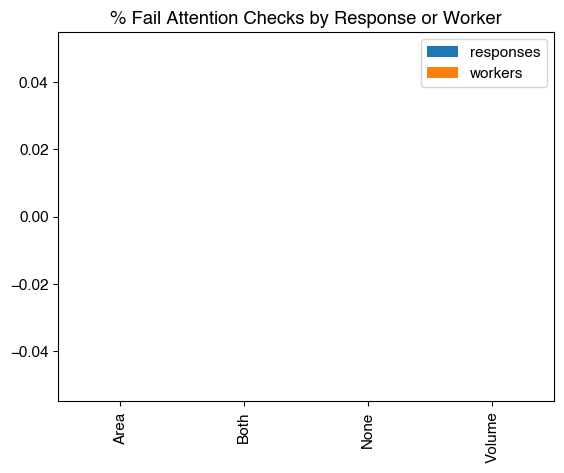

In [10]:
mturk_dfs(scenario, num_scenarios)
print()
llm_dfs(scenario, print_size=True)
pass

## How good are the LLMs at the qualificaiton task?

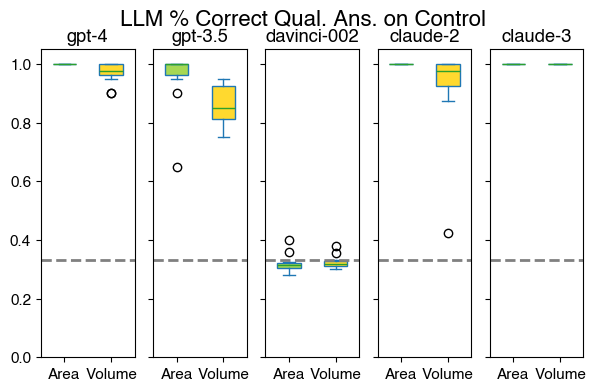

In [11]:
# Todo: why is show_charts false? I thought I had fixed this bug elsewhere... investigate!

llm_qual_area_chat = "temp=1_api=chat_qualification=True_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv"
llm_qual_area_comp = "temp=1_api=completion_qualification=True_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv"

llm_qual_vol_chat = "temp=1_api=chat_qualification=True_show-charts=False_chart-type=volume_samples=10_zero-shot=False.csv"
llm_qual_vol_comp = "temp=1_api=completion_qualification=True_show-charts=False_chart-type=volume_samples=10_zero-shot=False.csv"

llm_qual_none_comp = "temp=1_api=completion_qualification=True_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv"
llm_qual_none_chat = "temp=1_api=chat_qualification=True_show-charts=False_chart-type=area_samples=10_zero-shot=False.csv"

llm_qual_both_comp = "temp=1_api=completion_qualification=True_show-charts=False_chart-type=both_samples=10_zero-shot=False.csv"
llm_qual_both_chat = "temp=1_api=chat_qualification=True_show-charts=False_chart-type=both_samples=10_zero-shot=False.csv"


dfs_area = llm_dfs(scenario, desired_condition=llm_qual_area_chat)
dfs_area += llm_dfs(scenario, desired_condition=llm_qual_area_comp)
dfs_volume = llm_dfs(scenario, desired_condition=llm_qual_vol_chat)
dfs_volume += llm_dfs(scenario, desired_condition=llm_qual_vol_comp)

# dfs_none = llm_dfs(scenario, desired_condition=llm_qual_none_comp)
# dfs_none += llm_dfs(scenario, desired_condition=llm_qual_none_chat)

# dfs_both = llm_dfs(scenario, desired_condition=llm_qual_both_comp)
# dfs_both += llm_dfs(scenario, desired_condition=llm_qual_both_chat)

# TODO: issue where are the none and both cases on the qualificaiton task?

result = {}

for model in MODELS:
    result[model] = []

for df in dfs_area:
    right_answer = not_null_ties(control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = "Area"
    result[df.name].append(right_answer.to_frame())

for df in dfs_volume:
    right_answer = not_null_ties(control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = "Volume"
    result[df.name].append(right_answer.to_frame())

# The responses of each model for each condition of 'area' and "volume" should be the same
results = []
fig, ax = plt.subplots(ncols=5, sharey=True, figsize=(7, 4))
fig.suptitle("LLM % Correct Qual. Ans. on Control", fontsize=16)
for i in range(len(MODELS)):
    model = MODELS[i]
    res = pd.concat(result[model])

    _, bplot = res.plot.box(
        title=model, ax=ax[i], widths=0.5, patch_artist=True, return_type="both"
    )
    for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())[:2]):
        patch.set_facecolor(color)
    ax[i].set_ylim(0, 1.05)
    plot_random(ax[i])

plt.savefig("figures/llm_qual_control.pdf", bbox_inches="tight")
plt.show()

## example generations

In [12]:
desired_json_ex = "W3sidXRpbGl0eSI6IDUxLjAsICJhZ2VudCI6ICJhcHBsZS3wn42OIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJvbmUifSwgeyJ1dGlsaXR5IjogMS4wLCAiYWdlbnQiOiAiYmVlLfCfkJ0iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogIm9uZSJ9LCB7InV0aWxpdHkiOiAxLjAsICJhZ2VudCI6ICJjb3ct8J+QriIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAib25lIn0sIHsidXRpbGl0eSI6IDEuMCwgImFnZW50IjogImFwcGxlLfCfjY4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogInR3byJ9LCB7InV0aWxpdHkiOiAxMDEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogMTAxLjAsICJhZ2VudCI6ICJjb3ct8J+QriIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAidHdvIn0sIHsidXRpbGl0eSI6IDUxLjAsICJhZ2VudCI6ICJhcHBsZS3wn42OIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0aHJlZSJ9LCB7InV0aWxpdHkiOiA1MS4wLCAiYWdlbnQiOiAiYmVlLfCfkJ0iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogInRocmVlIn0sIHsidXRpbGl0eSI6IDUxLjAsICJhZ2VudCI6ICJjb3ct8J+QriIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAidGhyZWUifV0="

# this one we had been using because it has a more clear cuboid but the sum/product tradeoff is not as clear

desired_json = "W3sidXRpbGl0eSI6IDEwMS4wLCAiYWdlbnQiOiAiYXBwbGUt8J+NjiIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAib25lIn0sIHsidXRpbGl0eSI6IDEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJvbmUifSwgeyJ1dGlsaXR5IjogMS4wLCAiYWdlbnQiOiAiY293LfCfkK4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogIm9uZSJ9LCB7InV0aWxpdHkiOiAxLjAsICJhZ2VudCI6ICJhcHBsZS3wn42OIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogNTEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogNTEuMCwgImFnZW50IjogImNvdy3wn5CuIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogMS4wLCAiYWdlbnQiOiAiYXBwbGUt8J+NjiIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAidGhyZWUifSwgeyJ1dGlsaXR5IjogNTEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0aHJlZSJ9LCB7InV0aWxpdHkiOiAxLjAsICJhZ2VudCI6ICJjb3ct8J+QriIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAidGhyZWUifV0="

desired_json_from_graph = "W3sidXRpbGl0eSI6IDEuMCwgImFnZW50IjogImFwcGxlLfCfjY4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogIm9uZSJ9LCB7InV0aWxpdHkiOiA1MS4wLCAiYWdlbnQiOiAiYmVlLfCfkJ0iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogIm9uZSJ9LCB7InV0aWxpdHkiOiA1MS4wLCAiYWdlbnQiOiAiY293LfCfkK4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogIm9uZSJ9LCB7InV0aWxpdHkiOiAxLjAsICJhZ2VudCI6ICJhcHBsZS3wn42OIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogNTEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0d28ifSwgeyJ1dGlsaXR5IjogMS4wLCAiYWdlbnQiOiAiY293LfCfkK4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogInR3byJ9LCB7InV0aWxpdHkiOiAxMDEuMCwgImFnZW50IjogImFwcGxlLfCfjY4iLCAiY3JlZGVuY2UiOiAzMy4wLCAiYWN0aW9uIjogInRocmVlIn0sIHsidXRpbGl0eSI6IDEuMCwgImFnZW50IjogImJlZS3wn5CdIiwgImNyZWRlbmNlIjogMzMuMCwgImFjdGlvbiI6ICJ0aHJlZSJ9LCB7InV0aWxpdHkiOiAxLjAsICJhZ2VudCI6ICJjb3ct8J+QriIsICJjcmVkZW5jZSI6IDMzLjAsICJhY3Rpb24iOiAidGhyZWUifV0="

# this one does not actually appear in the generations; possibly it was from an old generation

In [13]:
desired_json_ex == desired_json_from_graph

False

In [14]:
claude_area_qual = llm_dfs(
    scenario,
    qualification=True,
    aggregate_responses=False,
    desired_condition="area",
    desired_model="claude-2",
)[0]
claude_volume_qual = llm_dfs(
    scenario,
    qualification=True,
    aggregate_responses=False,
    desired_condition="volume",
    desired_model="claude-2",
)[0]
claude_ex_qual_volume = claude_volume_qual[
    claude_volume_qual["scenario_json"] == desired_json
].iloc[0]
claude_ex_qual_area = claude_area_qual[
    claude_area_qual["scenario_json"] == desired_json
].iloc[0]

claude_area = llm_dfs(
    scenario,
    qualification=False,
    aggregate_responses=False,
    desired_condition="show-charts=True_chart-type=area",
    desired_model="claude-2",
)[0]
claude_volume = llm_dfs(
    scenario,
    qualification=False,
    aggregate_responses=False,
    desired_condition="volume",
    desired_model="claude-2",
)[0]
claude_ex_volume = claude_volume[claude_volume["scenario_json"] == desired_json].iloc[0]
claude_ex_area = claude_area[claude_area["scenario_json"] == desired_json].iloc[0]

In [15]:
# TODO: apply this eval throughout
# TODO: need to be clear that the qualificaiton task for the models is not the same exact one as for people. Rather
# We give them the qualification questions and answers and then test how well they can calculate NBS, MEC on each of the items
# in the scenario

In [16]:
print(claude_ex_area["full"])



Human: Follow the given examples and answer the questions. Give exactly one answer.

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There is 1 proposal:
- proposal one: with an outcome of 20 for group A, and 10 for group B.

Which of the proposal(s) takes up the largest total volume?
- (A) Proposal one

Assistant: Let's think step by step. The total volume for a proposal is calculated by multiplying the proposed outcome raised to the (normalized) group size for each group.

For proposal one, the total volume is 20 ** 0.5 (for group "A") + 10 ** 0.5 (for group "B") = 4.47213595499958 * 3.1622776601683795 = 14.1.

Therefore, for the question of which proposal takes up the largest volume area, the answer is (A) Proposal one.

Human: Summarize your answer to the question above by writing only the proposal letter.

Assistant: A

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B wi

In [17]:
print(claude_ex_volume["full"])



Human: Follow the given examples and answer the questions. Give exactly one answer.

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There is 1 proposal:
- proposal one: with an outcome of 20 for group A, and 10 for group B.

Which of the proposal(s) takes up the largest total volume?
- (A) Proposal one

Assistant: Let's think step by step. The total volume for a proposal is calculated by multiplying the proposed outcome raised to the (normalized) group size for each group.

For proposal one, the total volume is 20 ** 0.5 (for group "A") + 10 ** 0.5 (for group "B") = 4.5 * 3.2 = 14.1.

Therefore, for the question of which proposal takes up the largest volume area, the answer is (A) Proposal one.

Human: Summarize your answer to the question above by writing only the proposal letter.

Assistant: A

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There i

In [18]:
print(claude_ex_qual_area["full"])



Human: Follow the given examples and answer the questions. Give exactly one answer.

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There is 1 proposal:
- proposal one: with an outcome of 20 for group A, and 10 for group B.

Which of the proposal(s) takes up the largest total volume?
- (A) Proposal one

Assistant: Let's think step by step. The total volume for a proposal is calculated by multiplying the proposed outcome raised to the (normalized) group size for each group.

For proposal one, the total volume is 20 ** 0.5 (for group "A") + 10 ** 0.5 (for group "B") = 4.47213595499958 * 3.1622776601683795 = 14.1.

Therefore, for the question of which proposal takes up the largest volume area, the answer is (A) Proposal one.

Human: Summarize your answer to the question above by writing only the proposal letter.

Assistant: A

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B wi

In [19]:
print(claude_ex_qual_volume["full"])



Human: Follow the given examples and answer the questions. Give exactly one answer.

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There is 1 proposal:
- proposal one: with an outcome of 20 for group A, and 10 for group B.

Which of the proposal(s) takes up the largest total volume?
- (A) Proposal one

Assistant: Let's think step by step. The total volume for a proposal is calculated by multiplying the proposed outcome raised to the (normalized) group size for each group.

For proposal one, the total volume is 20 ** 0.5 (for group "A") + 10 ** 0.5 (for group "B") = 4.5 * 3.2 = 14.1.

Therefore, for the question of which proposal takes up the largest volume area, the answer is (A) Proposal one.

Human: Summarize your answer to the question above by writing only the proposal letter.

Assistant: A

Human: In this scenario, there are 2 groups:
- group A with 10 people in it, and 
- group B with 10 people in it.

There i

In [20]:
claude_area = llm_dfs(
    scenario,
    qualification=False,
    aggregate_responses=False,
    desired_condition="area",
    desired_model="claude-2",
)[1]
claude_volume = llm_dfs(
    scenario,
    qualification=False,
    aggregate_responses=False,
    desired_condition="volume",
    desired_model="claude-2",
)[0]
claude_ex_volume = claude_volume[claude_volume["scenario_json"] == desired_json_ex]
claude_ex_area = claude_area[claude_area["scenario_json"] == desired_json_ex]

In [21]:
dfs = llm_dfs(
    scenario,
    qualification=False,
    aggregate_responses=False,
    desired_condition="area",
    desired_model="claude-2",
)

In [22]:
dfs[0].name

'None'

In [23]:
# print(claude_area.iloc[0]['full'])

In [24]:
# print(claude_volume.iloc[0]['full'])

### Control Analysis

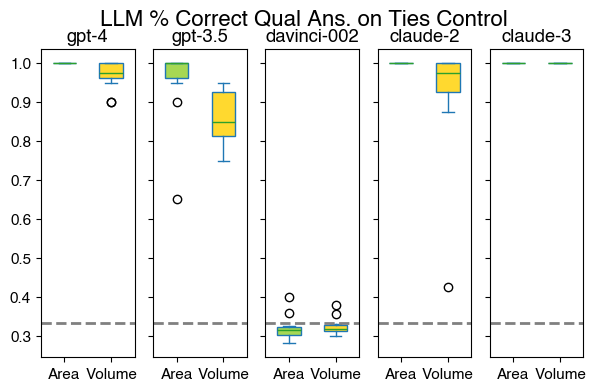

In [25]:
# This doesn't really look different than the last

result = {}

for model in MODELS:
    result[model] = []

for df in dfs_area:
    right_answer = control(not_null_ties(df)).apply(get_mec_percent, axis=1)
    right_answer.name = "Area"
    result[df.name].append(right_answer.to_frame())

for df in dfs_volume:
    right_answer = control(not_null_ties(df)).apply(get_nbs_percent, axis=1)
    right_answer.name = "Volume"
    result[df.name].append(right_answer.to_frame())

fig, ax = plt.subplots(ncols=5, sharey=True, figsize=(7, 4))
fig.suptitle("LLM % Correct Qual Ans. on Ties Control", fontsize=16)
for i in range(len(MODELS)):
    model = MODELS[i]
    res = pd.concat(result[model])
    _, bplot = res.plot.box(
        title=model, ax=ax[i], widths=0.5, patch_artist=True, return_type="both"
    )
    for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())[:2]):
        patch.set_facecolor(color)
    plot_random(ax[i])

In [26]:
# same issue as above
gpt4_dfs_qual = llm_dfs(
    scenario, desired_model="gpt4", desired_condition=llm_qual_area_chat
)
gpt4_dfs_qual += llm_dfs(
    scenario, desired_model="gpt4", desired_condition=llm_qual_none_chat
)
gpt4_dfs_qual += llm_dfs(
    scenario, desired_model="gpt4", desired_condition=llm_qual_none_chat
)
# percent_correct_area_by_condition(dfs_area, "area")

In [27]:
# print the task for use in slides
# print(dfs_area[2].iloc[0]['full'])

In [28]:
# Only necessary for chat models
# import ast
# dialogue = ast.literal_eval(dfs_area[0].iloc[0]['full'])
# result = []
# for chat in dialogue:
#     result += [(k, v) for k, v in chat.items()]
# print(model_experiment.dialogue_to_string(result))

In [29]:
# gpt4_vol_qual = dfs_volume[1]
# not_equal = gpt4_vol_qual[gpt4_vol_qual['response'] != gpt4_vol_qual['scenario_nbs']]
# equal = gpt4_vol_qual[gpt4_vol_qual['response'] == gpt4_vol_qual['scenario_nbs']]
# print(f'% not equal gpt-4: {len(not_equal) / len(gpt4_vol_qual)}')
# print(f'% not equal gpt-4, no ties: {len(not_null_ties(not_equal)) / len(not_null_ties(gpt4_vol_qual))}')

# # wrong number of groups, hallucinated a sum, mostly from ties
# index = 1
# df = not_null_ties(not_equal)
# row = df.iloc[index]
# print(pm.decode_gameState(row['scenario_json']))
# print(row)
# ast.literal_eval(row['text'])[1]
# # import ast
# # dialogue = ast.literal_eval(not_equal.iloc[0]['full'])
# # result = []
# # for chat in dialogue:
# #     result += [(k, v) for k, v in chat.items()]
# # result

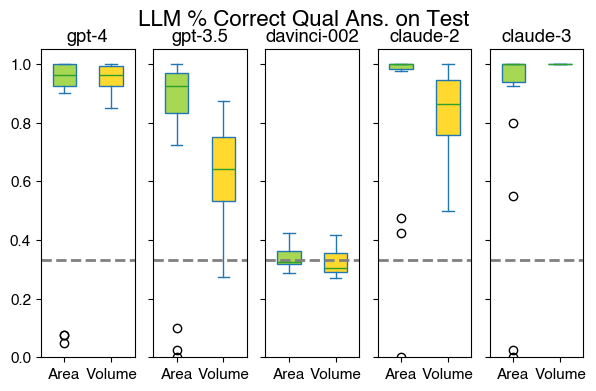

In [30]:
result = {}

for model in MODELS:
    result[model] = []

for df in dfs_area:
    right_answer = test(df).apply(get_mec_percent, axis=1)
    right_answer.name = "Area"
    result[df.name].append(right_answer.to_frame())

for df in dfs_volume:
    right_answer = test(df).apply(get_nbs_percent, axis=1)
    right_answer.name = "Volume"
    result[df.name].append(right_answer.to_frame())

fig, ax = plt.subplots(ncols=5, sharey=True, figsize=(7, 4))
fig.suptitle("LLM % Correct Qual Ans. on Test", fontsize=16)
for i in range(len(MODELS)):
    model = MODELS[i]
    res = pd.concat(result[model])
    _, bplot = res.plot.box(
        title=model, ax=ax[i], widths=0.5, return_type="both", patch_artist=True
    )
    for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())[:2]):
        patch.set_facecolor(color)
    ax[i].set_ylim(0, 1.05)
    plot_random(ax[i])

plt.savefig("figures/llm_qual_test.pdf", bbox_inches="tight")
plt.savefig("figures/llm_qual_test.svg", bbox_inches="tight", transparent=True)
plt.show()
# we would expect to see high agreement for both of these conditions and low agreement for the reversed

## Main plotting functions

# How often are they correct for control?

In [31]:
models_to_dfs, models_to_dfs_no_agg = get_all_llm_dfs(scenario)

In [32]:
random_models_to_dfs, random_models_to_dfs_no_agg = get_all_llm_dfs(random_scenario)

In [33]:
# llm_dfs_area_chart[2].iloc[1]['scenario_json'] == desired_json_ex

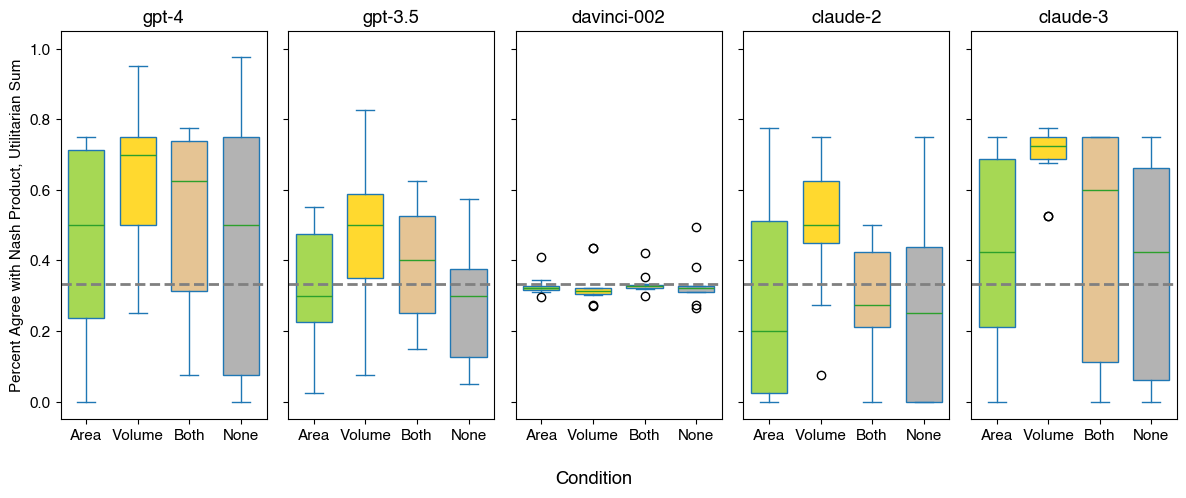

In [34]:
result = {}

for model in models_to_dfs:
    for df in models_to_dfs[model]:
        right_answer = control(df).apply(get_mec_percent, axis=1)
        right_answer.name = df.name
        if model not in result:
            result[model] = []
        result[model].append(right_answer.to_frame())

# # TODO: put a dashed line at 33% for random chance

fig, ax = plt.subplots(ncols=5, sharey=True, figsize=(12, 5))
# fig.suptitle('LLM % Correct Answer on Control', fontsize=16)
for i in range(len(MODELS)):
    model = MODELS[i]
    res = pd.concat(result[model])
    _, bplot = res.plot.box(
        title=model,
        ax=ax[i],
        widths=BOX_PLOT_WIDTH,
        ylim=PERCENT_PLT_YLIM,
        ylabel=f"Percent Agree with {nbs_long}, {mec_long}",
        patch_artist=True,
        return_type="both",
    )
    for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())):
        patch.set_facecolor(color)
    plot_random(ax[i])
fig.supxlabel("Condition")
plt.tight_layout()
plt.savefig("figures/llm_control_means.pdf", bbox_inches="tight")
plt.savefig("figures/llm_control_means.svg", bbox_inches="tight", transparent=True)
plt.tight_layout()
plt.show()

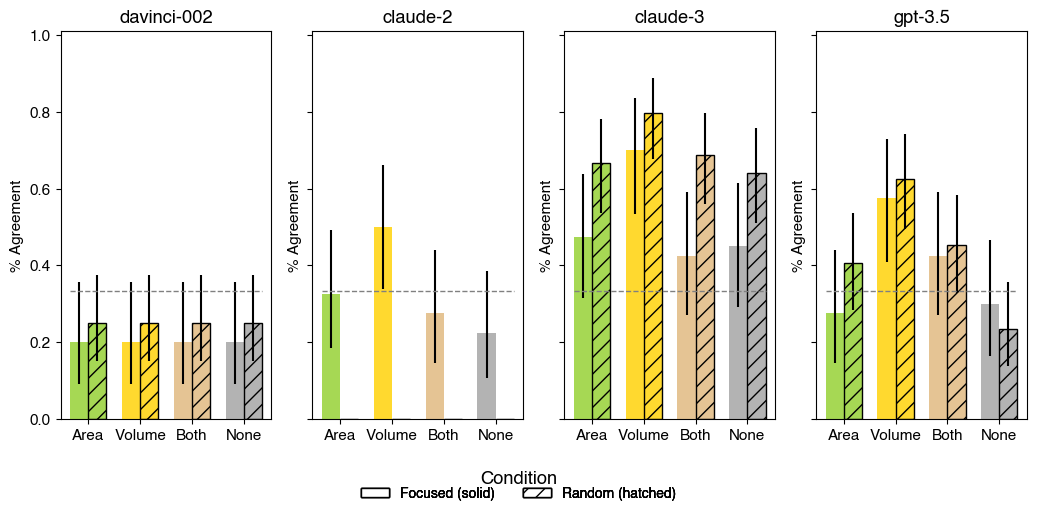

In [35]:
fig, ax = plt.subplots(
    ncols=4,
    sharey=True,
    figsize=(((LLM_TEST_PLOT_WIDTH * len(CONDITION_ORDER)) / 2 + 0.2) * len(MODELS), 5),
)
for i, model in enumerate(set(MODELS) - set(["gpt-4"])):
    plot_control_focused_vs_random_binomial(
        dfs_focused=models_to_dfs_no_agg[model],
        dfs_random=random_models_to_dfs_no_agg[model],
        title=model,
        fig=fig,
        ax=ax[i],
    )
fig.supxlabel("Condition")

save_fig(fig, "llm_control")

In [36]:
# fig, ax = plt.subplots(ncols=3, sharey=True, figsize=(((LLM_TEST_PLOT_WIDTH * len(CONDITION_ORDER)) / 2 + .2) * len(MODELS) , 5))
# for i, model in enumerate(set(MODELS) - set(['gpt-4'])):
#     dfs = list(models_to_dfs_no_agg.values())
#     plot_control_binomial(models_to_dfs_no_agg[model], title=model, ax=ax[i], between=('scenario_nbs', 'scenario_fehr'))
# fig.supxlabel('Condition')

# save_fig(fig, 'llm_control')

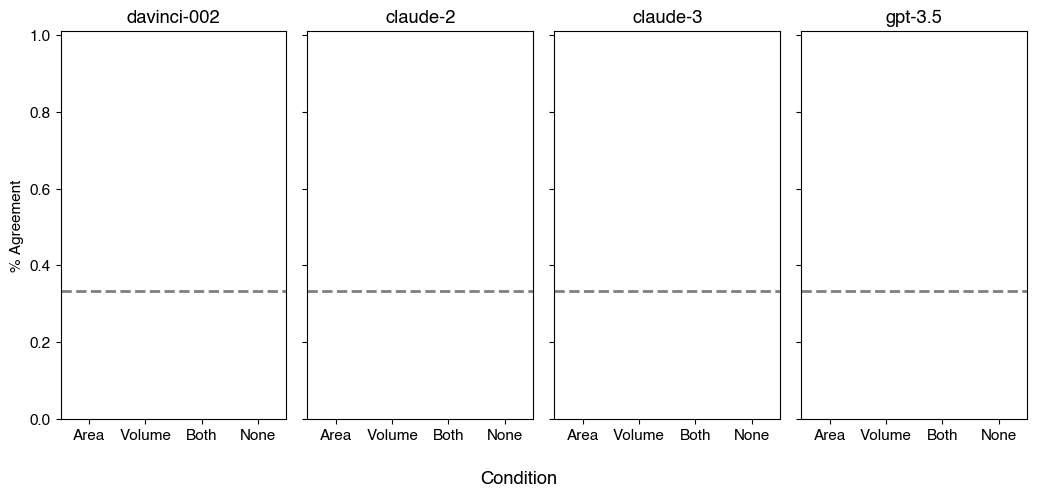

In [37]:
fig, ax = plt.subplots(
    ncols=4,
    sharey=True,
    figsize=(((LLM_TEST_PLOT_WIDTH * len(CONDITION_ORDER)) / 2 + 0.2) * len(MODELS), 5),
)
for i, model in enumerate(set(MODELS) - set(["gpt-4"])):
    dfs = list(models_to_dfs_no_agg.values())
    plot_control_binomial(
        models_to_dfs_no_agg[model], title=model, ax=ax[i], blank=True
    )
fig.supxlabel("Condition")

save_fig(fig, "llm_control_blank")

<Axes: title={'center': 'gpt-4'}, ylabel='% Agreement'>

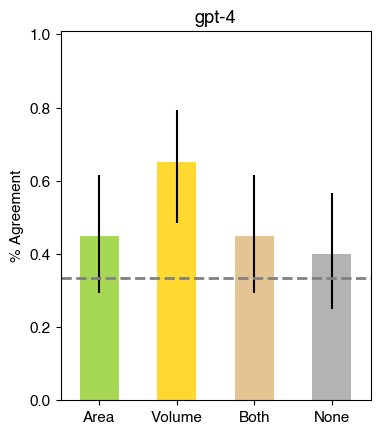

In [38]:
model = "gpt-4"

dfs = list(models_to_dfs_no_agg.values())
dfs = models_to_dfs_no_agg[model]

fig, ax = plt.subplots(ncols=1, sharey=True, figsize=(1 + ((3 / 4) * len(dfs)), 4.8))

plot_control_binomial(dfs, title=model, ax=ax)

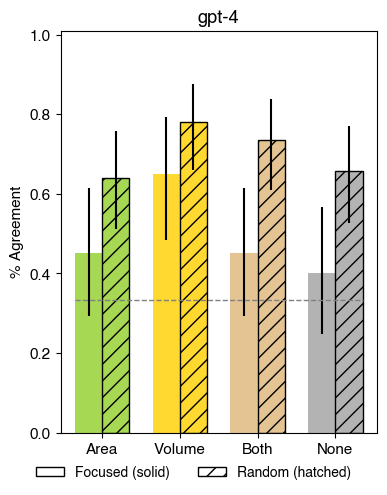

In [39]:
model = "gpt-4"

fig, ax = plot_control_focused_vs_random_binomial(
    dfs_focused=models_to_dfs_no_agg[model],
    dfs_random=random_models_to_dfs_no_agg[model],
    title=model,
)
save_fig(fig, "gpt-4_control")

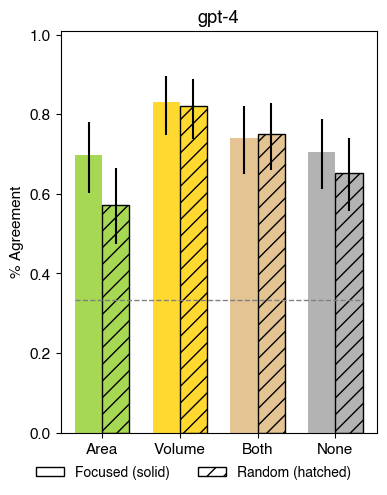

In [40]:
model = "gpt-4"

fig, ax = plot_control_focused_vs_random_binomial(
    dfs_focused=models_to_dfs_no_agg[model],
    dfs_random=random_models_to_dfs_no_agg[model],
    title=model,
    between=("scenario_nbs", "scenario_fehr"),
)
save_fig(fig, "gpt-4_control_fehr_nash")

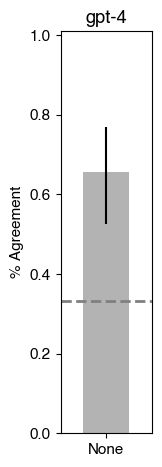

In [41]:
model = "gpt-4"

dfs = list(random_models_to_dfs_no_agg.values())
dfs = random_models_to_dfs_no_agg[model]
dfs = list(filter(lambda x: x.name == "None", dfs))

fig, ax = plt.subplots(ncols=1, sharey=True, figsize=(1 + ((3 / 4) * len(dfs)), 4.8))
ax.set_xlabel("")

plot_control_binomial(dfs, title=model, ax=ax)

save_fig(fig, "gpt-4_random_control_none")

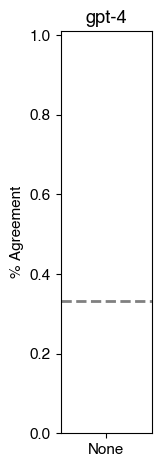

In [42]:
model = "gpt-4"

dfs = list(random_models_to_dfs_no_agg.values())
dfs = random_models_to_dfs_no_agg[model]
dfs = list(filter(lambda x: x.name == "None", dfs))

fig, ax = plt.subplots(ncols=1, sharey=True, figsize=(1 + ((3 / 4) * len(dfs)), 4.8))
ax.set_xlabel("")

plot_control_binomial(dfs, title=model, ax=ax, blank=True)

save_fig(fig, "gpt-4_random_control_none_blank")

In [43]:
# model = 'gpt-4'

# dfs = list(random_models_to_dfs_no_agg.values())
# dfs = random_models_to_dfs_no_agg[model]

# fig, ax = plt.subplots(ncols=1, sharey=True, figsize=(1 + ((3 / 4) * len(dfs)),4.8))

# plot_control_binomial(dfs, title=f'{model}', ax=ax)

# save_fig(fig, 'gpt-4_random_control')

In [44]:
# has_axis = [True, True, True, True, True]
# for i in range(len(models_to_dfs)):
#     model = MODELS[i]
#     plot_conditions_distribution(models_to_dfs[model], test, model, axis=has_axis[i])
#     plt.tight_layout()
#     plt.savefig(f"figures/{model}_test_condition_means.pdf", bbox_inches='tight')
#     plt.savefig(f"figures/{model}_test_condition_means.svg", bbox_inches='tight', transparent=True)
#     plt.tight_layout()
#     plt.show()

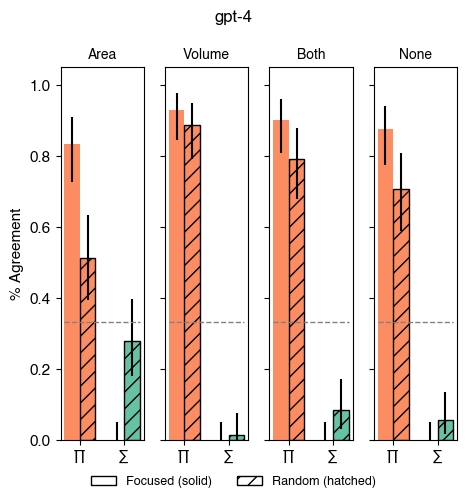

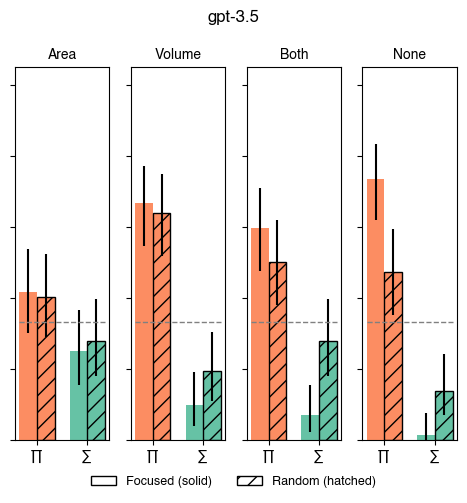

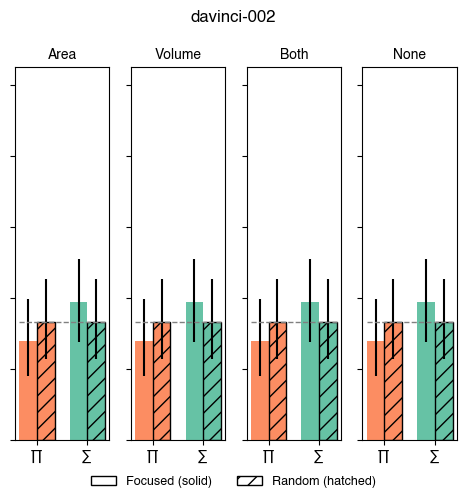

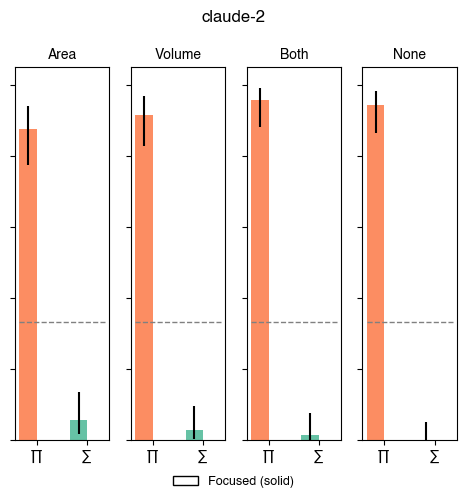

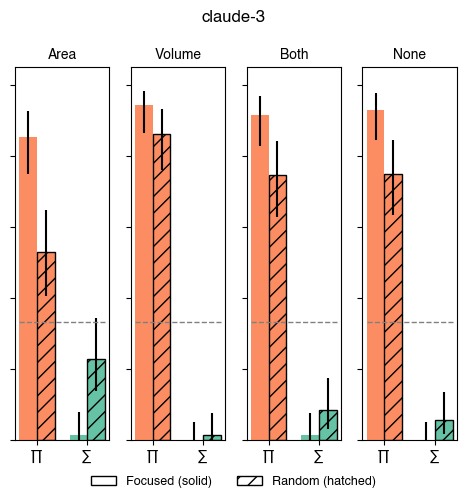

In [45]:
has_axis = [True, False, False, False, False]
for i in range(len(models_to_dfs_no_agg)):
    model = MODELS[i]

    focused_dfs = models_to_dfs_no_agg[model]
    random_dfs = random_models_to_dfs_no_agg[model]

    fig = plot_focused_vs_random(
        dfs_focused=focused_dfs,
        dfs_random=random_dfs,
        selector=test,
        title=model,
        has_axis=has_axis[i],
    )
    # save_fig(fig, f"{model}_focused_vs_random_test")
    # fig = plot_conditions_binomial(models_to_dfs_no_agg[model], test, model, axis=has_axis[i])
    save_fig(fig, f"{model}_test_condition")

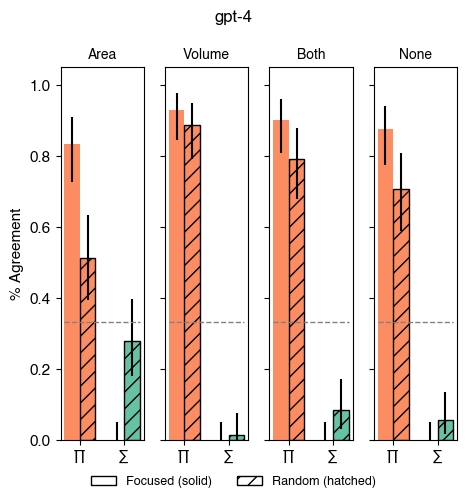

In [46]:
model = "gpt-4"
focused_dfs = models_to_dfs_no_agg[model]
random_dfs = random_models_to_dfs_no_agg[model]

fig = plot_focused_vs_random(
    dfs_focused=focused_dfs,
    dfs_random=random_dfs,
    selector=test,
    between=("scenario_nbs", "scenario_mec"),
    title=model,
)
save_fig(fig, f"{model}_test_condition")

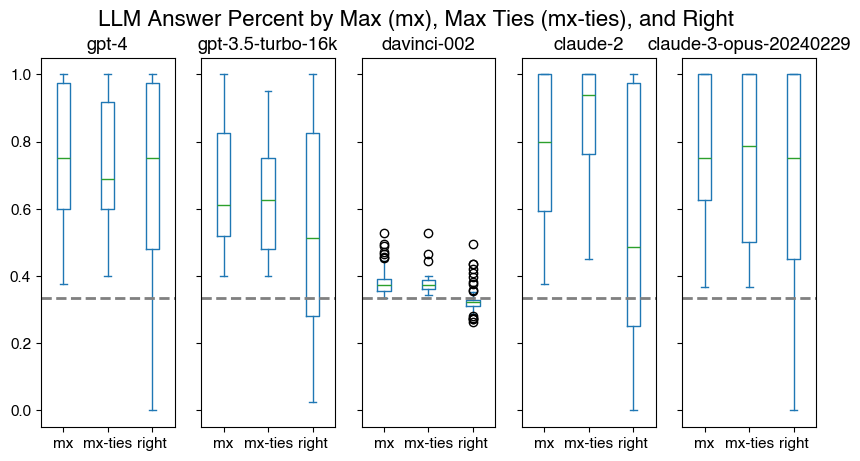

In [47]:
# You would actually expect the probability of the max answer to go down more on the ties!

fig, ax = plt.subplots(ncols=5, sharey=True, figsize=(10, 4.8))
fig.suptitle(
    "LLM Answer Percent by Max (mx), Max Ties (mx-ties), and Right", fontsize=16
)

for i in range(len(MODELS_LONG)):
    model = MODELS_LONG[i]
    df = pd.concat(llm_dfs(scenario, desired_model=model))
    df.name = model
    # TODO: double check control cases only!
    plot_answer_distribution(df, ax=ax[i])
    plot_random(ax[i])

plt.savefig(f"figures/llm_max_ties_right.pdf", bbox_inches="tight")
plt.show()

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4
Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4
Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4


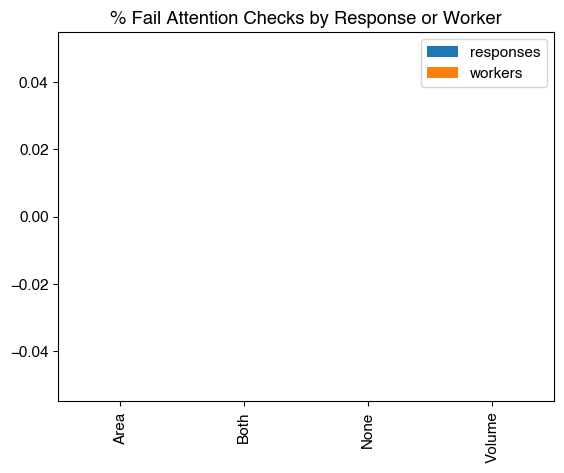

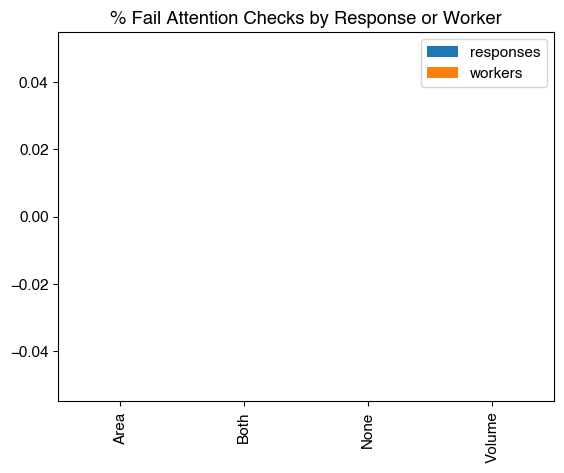

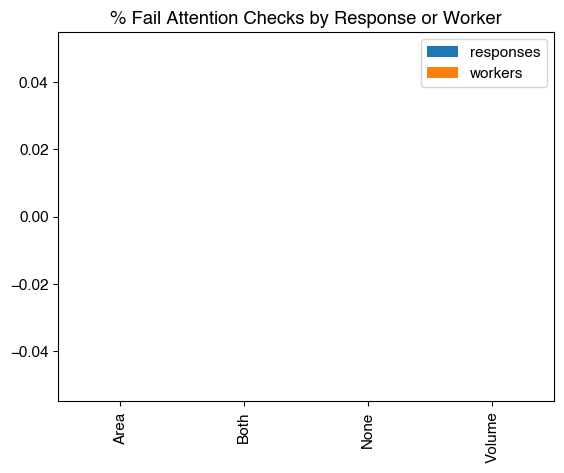

In [48]:
# TODO: why are so many failing attention checks?? It's about 25% right now...

m_dfs = mturk_dfs(scenario, num_scenarios=num_scenarios)
m_dfs_delete_user = mturk_dfs(
    scenario, num_scenarios=num_scenarios, delete_user_fail_check=True
)
m_dfs_filter_control = mturk_dfs(
    scenario, num_scenarios=num_scenarios, filter_control=True
)

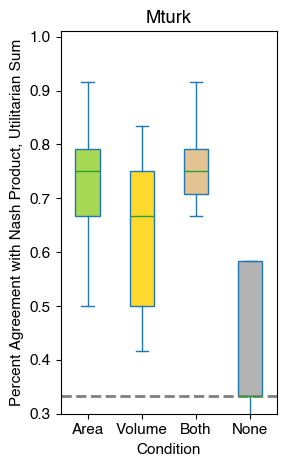

In [49]:
result = []

m_dfs_delete_user = sorted(
    m_dfs_delete_user, key=lambda x: CONDITION_ORDER.index(x.name)
)

for df in m_dfs_delete_user:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

ax, bplot = pd.concat(result).plot.box(
    title="Mturk",
    figsize=(3, 4.8),
    ylim=(0.3, 1.01),
    ylabel=f"Percent Agreement with {nbs_long}, {mec_long}",
    xlabel="Condition",
    patch_artist=True,
    return_type="both",
)
for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())):
    patch.set_facecolor(color)
plot_random(ax)
plt.tight_layout()
plt.savefig(f"figures/mturk_control_means.pdf", bbox_inches="tight")
plt.savefig(f"figures/mturk_control_means.svg", bbox_inches="tight", transparent=True)
plt.show()

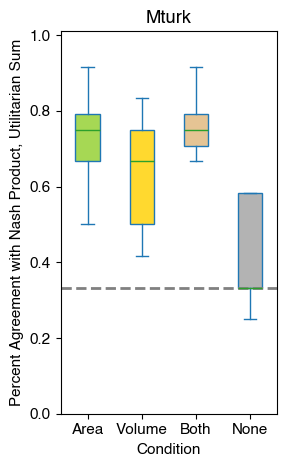

In [50]:
result = []

m_dfs_delete_user = sorted(
    m_dfs_delete_user, key=lambda x: CONDITION_ORDER.index(x.name)
)

for df in m_dfs_delete_user:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

ax, bplot = pd.concat(result).plot.box(
    title="Mturk",
    figsize=(3, 4.8),
    ylim=(0, 1.01),
    ylabel=f"Percent Agreement with {nbs_long}, {mec_long}",
    xlabel="Condition",
    patch_artist=True,
    return_type="both",
)
for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())):
    patch.set_facecolor(color)
plot_random(ax)
plt.tight_layout()
plt.savefig(f"figures/mturk_control_means_full.pdf", bbox_inches="tight")
plt.savefig(
    f"figures/mturk_control_means_full.svg", bbox_inches="tight", transparent=True
)
plt.show()

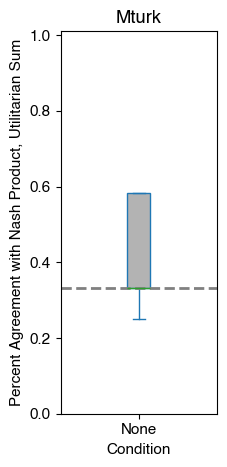

In [51]:
result = []

m_dfs_delete_user = sorted(
    m_dfs_delete_user, key=lambda x: CONDITION_ORDER.index(x.name)
)
none_only = list(filter(lambda x: x.name == "None", m_dfs_delete_user))

for df in none_only:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

ax, bplot = pd.concat(result).plot.box(
    title="Mturk",
    figsize=(2.4, 4.8),
    ylim=(0, 1.01),
    ylabel=f"Percent Agreement with {nbs_long}, {mec_long}",
    xlabel="Condition",
    patch_artist=True,
    return_type="both",
)
for patch, color in zip(bplot["boxes"], list(CONDITION_TO_COLOR.values())[3:]):
    patch.set_facecolor(color)
plot_random(ax)
plt.tight_layout()
plt.savefig(f"figures/mturk_control_means_full_none.pdf", bbox_inches="tight")
plt.savefig(
    f"figures/mturk_control_means_full_none.svg", bbox_inches="tight", transparent=True
)
plt.show()

None: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.2 and std 5.2 and wage $29.1


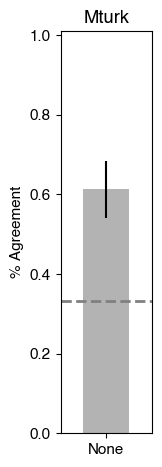

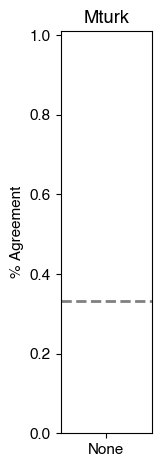

In [52]:
m_random_dfs = mturk_dfs(
    random_scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)

m_random_dfs = sorted(m_random_dfs, key=lambda x: CONDITION_ORDER.index(x.name))

fig = plot_control_binomial(m_random_dfs, "Mturk")
save_fig(fig, "mturk_random_control")

fig = plot_control_binomial(m_random_dfs, "Mturk", blank=True)
save_fig(fig, "mturk_random_control_blank")

None: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.2 and std 5.2 and wage $29.1


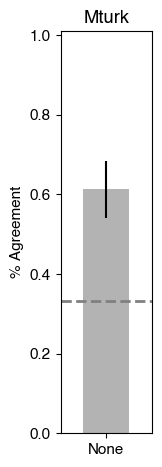

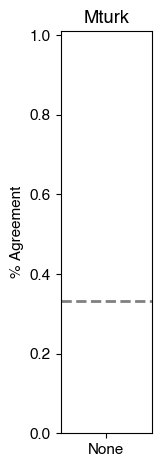

In [53]:
m_random_dfs = mturk_dfs(
    random_scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)

m_random_dfs = sorted(m_random_dfs, key=lambda x: CONDITION_ORDER.index(x.name))

none_only = list(filter(lambda x: x.name == "None", m_random_dfs))

fig = plot_control_binomial(none_only, "Mturk")
save_fig(fig, "mturk_random_control_none")

fig = plot_control_binomial(none_only, "Mturk", blank=True)
save_fig(fig, "mturk_random_control_none_blank")

In [54]:
m_dfs2 = mturk_dfs(
    scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)

m_dfs2 = sorted(m_dfs2, key=lambda x: CONDITION_ORDER.index(x.name))

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4


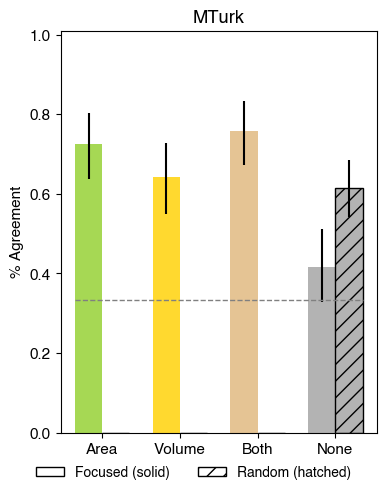

In [55]:
fig, ax = plot_control_focused_vs_random_binomial(
    dfs_focused=m_dfs2,
    dfs_random=m_random_dfs,
    title="MTurk",
)
save_fig(fig, "mturk_control")

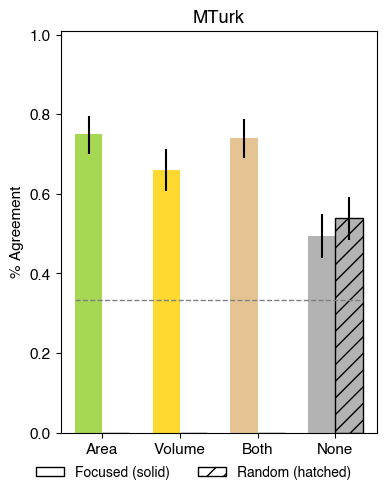

In [56]:
fig, ax = plot_control_focused_vs_random_binomial(
    dfs_focused=m_dfs2,
    dfs_random=m_random_dfs,
    title="MTurk",
    between=("scenario_nbs", "scenario_fehr"),
)
save_fig(fig, "mturk_control_fehr_nash")

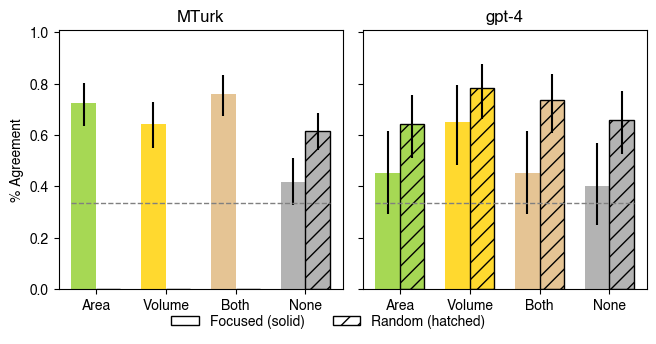

In [57]:
with plt.rc_context({"font.size": 10}):

    num = 8
    fig, ax = plt.subplots(
        ncols=2, sharey=True, figsize=(10 / 1.5, 5 / 1.5), squeeze=True
    )

    plot_control_focused_vs_random_binomial(
        dfs_focused=m_dfs2,
        dfs_random=m_random_dfs,
        title="MTurk",
        fig=fig,
        ax=fig.axes[0],
    )

    model = "gpt-4"

    plot_control_focused_vs_random_binomial(
        dfs_focused=models_to_dfs_no_agg[model],
        dfs_random=random_models_to_dfs_no_agg[model],
        title=model,
        has_axis=False,
        fig=fig,
        ax=fig.axes[1],
    )

    save_fig(fig, "mturk_gpt4_control")

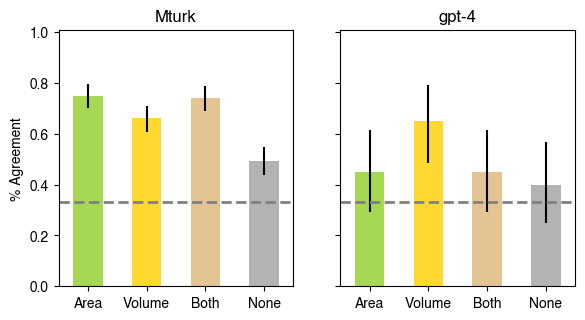

In [58]:
with plt.rc_context({"font.size": 10}):

    num = 8
    fig, ax = plt.subplots(
        ncols=2, sharey=True, figsize=(10 / 1.5, 5 / 1.5), squeeze=True
    )

    plot_control_binomial(
        m_dfs2, title="Mturk", ax=ax[0], between=("scenario_nbs", "scenario_fehr")
    )

    model = "gpt-4"

    dfs = list(models_to_dfs_no_agg.values())
    gpt4_dfs = models_to_dfs_no_agg[model]

    plot_control_binomial(gpt4_dfs, title=model, ax=ax[1])

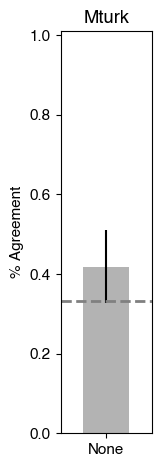

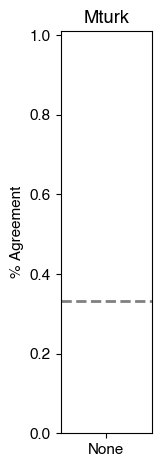

In [59]:
none_only = list(filter(lambda x: x.name == "None", m_dfs2))

fig = plot_control_binomial(none_only, "Mturk")
save_fig(fig, "mturk_control_none")

fig = plot_control_binomial(none_only, "Mturk", blank=True)
save_fig(fig, "mturk_control_none_blank")

## Do the agreement stats vary by scenario?

In [60]:
from IPython.display import display, HTML

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4


<Figure size 640x480 with 0 Axes>

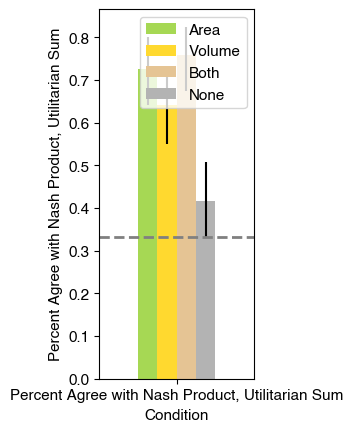

<Figure size 640x480 with 0 Axes>

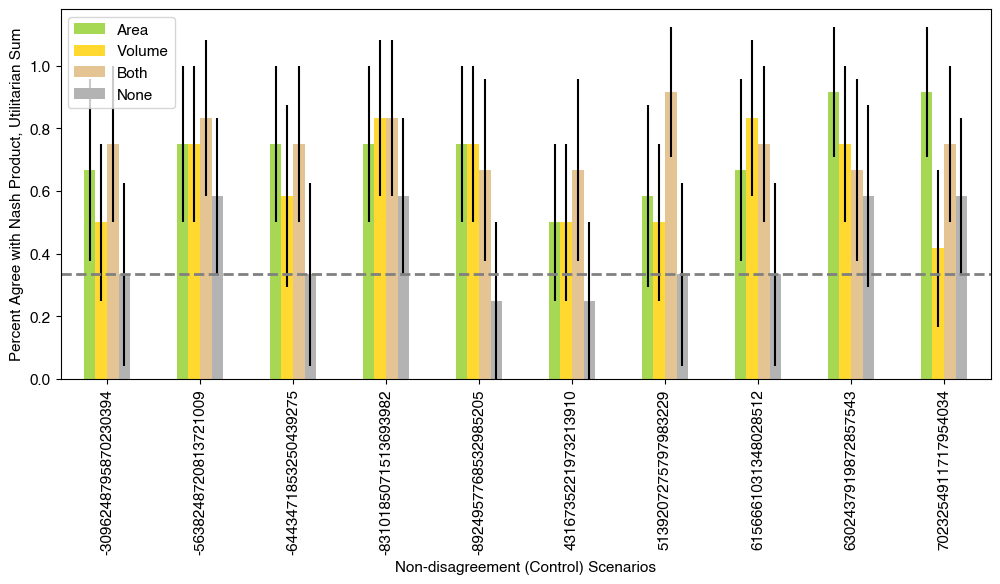

In [61]:
dfs = mturk_dfs(
    scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)
dfs = sort_by_condition(dfs)

plt.tight_layout()
plot_mean_control_agreement(dfs)
plt.savefig(f"figures/mturk_control_percent_agree.pdf", bbox_inches="tight")
plt.show()

plt.tight_layout()
plot_mean_control_agreement_scenario(dfs)
plt.savefig(f"figures/mturk_control_percent_agree_scenario.pdf", bbox_inches="tight")
plt.show()

In [62]:
np.array((5, 3)).mean()

4.0

<Axes: >

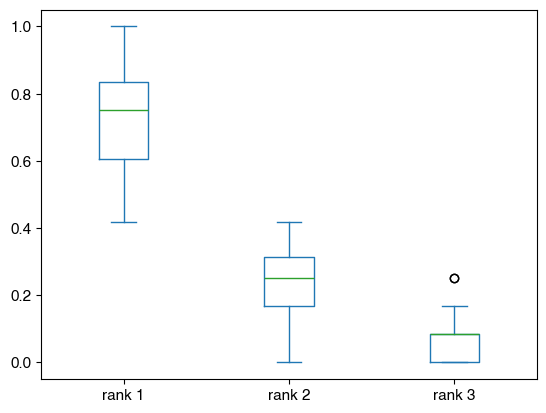

In [63]:
df = m_dfs_delete_user[0]

data = []
for i in range(3):
    series = df.apply(percent_by_position, position=i, axis=1)
    series.name = f"rank {i + 1}"
    data.append(series)

pd.concat(data, axis=1).plot.box()

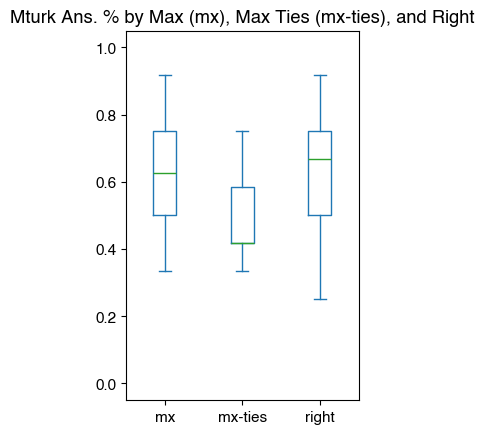

In [64]:
# You would actually expect the probability of the max answer to go down more on the ties!

# fig, ax = plt.subplots(ncols=4, sharey=True,
# fig.suptitle(, fontsize=16)

plot_answer_distribution(
    pd.concat(m_dfs_delete_user),
    figsize=(3, 4.8),
    ylim=PERCENT_PLT_YLIM,
    title="Mturk Ans. % by Max (mx), Max Ties (mx-ties), and Right",
)
plt.savefig(f"figures/mturk_max_ties_right.pdf", bbox_inches="tight")
plt.show()

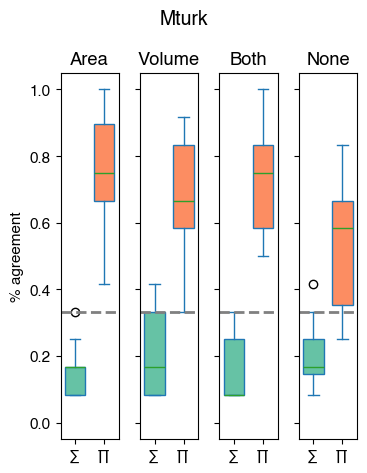

In [65]:
plot_conditions_distribution(m_dfs_delete_user, test, "Mturk")
plt.tight_layout()
plt.savefig(f"figures/mturk_test_condition_means.pdf", bbox_inches="tight")
plt.savefig(
    f"figures/mturk_test_condition_means.svg", bbox_inches="tight", transparent=True
)
plt.show()

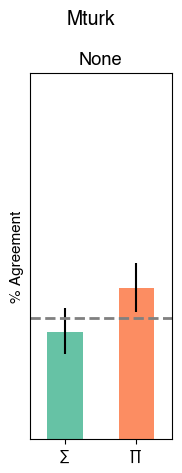

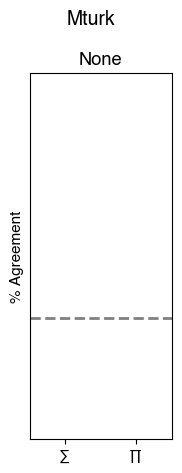

In [66]:
fig = plot_conditions_binomial(dfs=m_random_dfs, selector=test, title="Mturk")
save_fig(fig, "mturk_random_test_condition")

fig = plot_conditions_binomial(
    dfs=m_random_dfs, selector=test, title="Mturk", blank=True
)
save_fig(fig, "mturk_random_test_condition_blank")

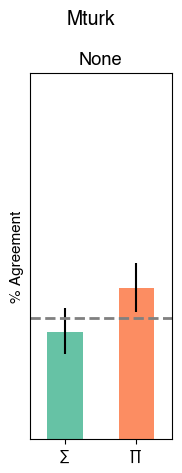

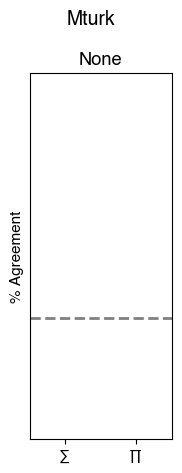

In [67]:
none_only = list(filter(lambda x: x.name == "None", m_random_dfs))

fig = plot_conditions_binomial(dfs=none_only, selector=test, title="Mturk")
save_fig(fig, "mturk_random_test_condition_none")

fig = plot_conditions_binomial(dfs=none_only, selector=test, title="Mturk", blank=True)
save_fig(fig, "mturk_random_test_condition_none_blank")

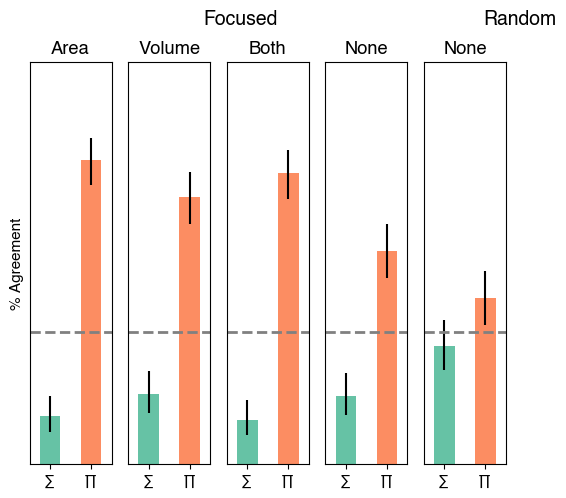

In [68]:
num = 5
fig, axes = plt.subplots(
    ncols=num, sharey=True, figsize=(1 + LLM_TEST_PLOT_WIDTH * num, 4.8)
)

plot_conditions_binomial(dfs=m_dfs2, selector=test, title="Focused", axes=axes[:-1])


none_only = list(filter(lambda x: x.name == "None", m_random_dfs))

plot_conditions_binomial(dfs=none_only, selector=test, title="Random", axes=axes[-1])

space_last_fig_add_titles(fig, axes)

save_fig(fig, f"mturk_test_condition")

In [69]:
def plot_focused_vs_random(
    dfs_focused,
    dfs_random,
    selector,
    between=("scenario_nbs", "scenario_mec"),
    hatch="//",
    figsize=None,
    order=CONDITION_ORDER,
    title=None,
    capsize=0,
    has_axis=True,
    fig=None,
    axes=None,
    has_legend=True,
):
    """
    Plots side-by-side (focused vs. random) bar‐pairs for each condition,
    including 95% binomial‐test error bars.

    dfs_focused, dfs_random: lists of DataFrames (same length & order)
    selector: function(df)->filtered df (e.g. test or control)
    between: which scenario_* columns to measure support for
    hatch: hatch pattern for the random bars
    capsize: errorbar cap size
    """
    n_conds = len(dfs_focused)
    if figsize is None:
        figsize = (1.2 * n_conds, 4.8)

    x = np.arange(len(between))
    width = 0.35

    # 1) build the union of condition‐names in the desired order
    names_f = {df.name for df in dfs_focused}
    names_r = {df.name for df in dfs_random}
    conds = [c for c in order if (c in names_f or c in names_r)]
    n_conds = len(conds)

    # 2) make your subplots
    if axes is None:
        fig, axes = plt.subplots(ncols=n_conds, sharey=True, figsize=figsize)
    if n_conds == 1:
        axes = [axes]

    # 3) loop over the union, pulling out df or None
    for idx, cond in enumerate(conds):
        ax = axes[idx]
        df_f = next((df for df in dfs_focused if df.name == cond), None)
        df_r = next((df for df in dfs_random if df.name == cond), None)

        # compute p, lower**, upper**

        colors = [AGGREGATION_TO_COLOR[fn] for fn in between]

        # focused bars (solid)
        if df_f is not None:
            f_sel = selector(df_f)
            p_f, low_f, high_f = zip(*(_binom_confidence(f_sel, fn) for fn in between))
            ax.bar(
                x - width / 2,
                p_f,
                width,
                color=colors,
                yerr=(low_f, high_f),
                capsize=capsize,
                label="Focused",
            )
        # random bars (hatched)
        if df_r is not None:
            r_sel = selector(df_r)
            p_r, low_r, high_r = zip(*(_binom_confidence(r_sel, fn) for fn in between))
            ax.bar(
                x + width / 2,
                p_r,
                width,
                color=colors,
                edgecolor="black",
                hatch=hatch,
                yerr=(low_r, high_r),
                capsize=capsize,
                label="Random",
            )

        ax.set_title(df_f.name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([FUNCTION_NAMES_TO_SHORT[fn] for fn in between])
        ax.set_ylim(0, 1.05)
        if not has_axis or idx > 0:
            ax.tick_params(labelleft=False)

        # horizontal random‐guess baseline
        ax.hlines(
            1 / 3,
            x.min() - width,
            x.max() + width,
            colors="grey",
            linestyles="--",
            lw=1,
        )
    axes[0].set_ylabel("% Agreement" if has_axis else "")
    # custom legend on first subplot
    handles = []
    if dfs_focused:
        handles.append(
            mpatches.Patch(
                facecolor="white", edgecolor="black", label="Focused (solid)"
            )
        )
    if dfs_random:
        handles.append(
            mpatches.Patch(
                facecolor="white",
                edgecolor="black",
                hatch=hatch,
                label="Random (hatched)",
            )
        )
    if has_legend:
        fig.legend(
            handles=handles,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.1),  # put it below the subplots
            ncol=2,
            frameon=False,
            fontsize=9,
        )
    if title:
        fig.suptitle(title, fontsize=12)
    # fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

In [70]:
def _binom_confidence(df, function, confidence=0.95):
    """
    For df and a column name `function`, compute:
      p = fraction of rows where response == df[function]
      low_err = p - lower_bound
      high_err = upper_bound - p
    using a two-sided binomial test CI.
    """
    sel = df["response"] == df[function]
    k = sel.sum()
    n = len(df)
    if n == 0:
        return 0.0, 0.0, 0.0
    test = binomtest(k=k, n=n, p=1 / 3, alternative="two-sided")
    ci_low, ci_hi = test.proportion_ci(confidence_level=confidence)
    p = k / n
    low_err = p - ci_low
    high_err = ci_hi - p
    return p, low_err, high_err

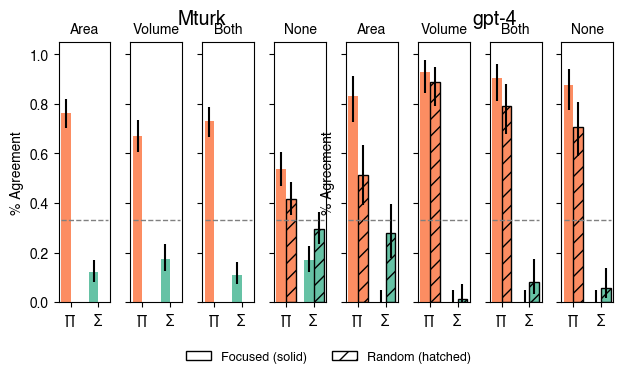

In [71]:
with plt.rc_context({"font.size": 10}):
    num = 8
    fig, axes = plt.subplots(ncols=num, sharey=True, figsize=(10 / 1.5, 5 / 1.5))

    plot_focused_vs_random(
        dfs_focused=m_dfs2,
        dfs_random=m_random_dfs,
        selector=test,
        # title='mturk',
        fig=fig,
        axes=axes[0:4],
    )

    model = "gpt-4"
    focused_dfs = models_to_dfs_no_agg[model]
    random_dfs = random_models_to_dfs_no_agg[model]

    plot_focused_vs_random(
        dfs_focused=focused_dfs,
        dfs_random=random_dfs,
        selector=test,
        # title=model,
        has_legend=False,
        fig=fig,
        axes=axes[4:],
    )

    extra_space = 0.05
    for i in range(4, 8):
        pos_last = axes[i].get_position()
        axes[i].set_position(
            [pos_last.x0 + extra_space, pos_last.y0, pos_last.width, pos_last.height]
        )

    top_row_suptitle = fig.text(0.31, 0.95, "Mturk", ha="center", fontsize=14)

    top_row_suptitle = fig.text(0.75, 0.95, "gpt-4", ha="center", fontsize=14)

    save_fig(fig, f"mturk_gpt4_test_condition")

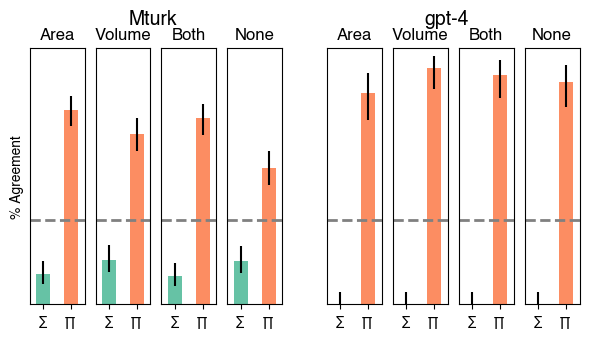

In [72]:
with plt.rc_context({"font.size": 10}):
    num = 8
    fig, axes = plt.subplots(ncols=num, sharey=True, figsize=(10 / 1.5, 5 / 1.5))

    plot_conditions_binomial(dfs=m_dfs2, selector=test, title="Focused", axes=axes[:4])

    model = "gpt-4"
    plot_conditions_binomial(
        models_to_dfs_no_agg[model], test, "Focused", axis=True, axes=axes[4:]
    )

    extra_space = 0.05
    for i in range(4, 8):
        pos_last = axes[i].get_position()
        axes[i].set_position(
            [pos_last.x0 + extra_space, pos_last.y0, pos_last.width, pos_last.height]
        )

    top_row_suptitle = fig.text(0.31, 0.95, "Mturk", ha="center", fontsize=14)

    top_row_suptitle = fig.text(0.75, 0.95, "gpt-4", ha="center", fontsize=14)

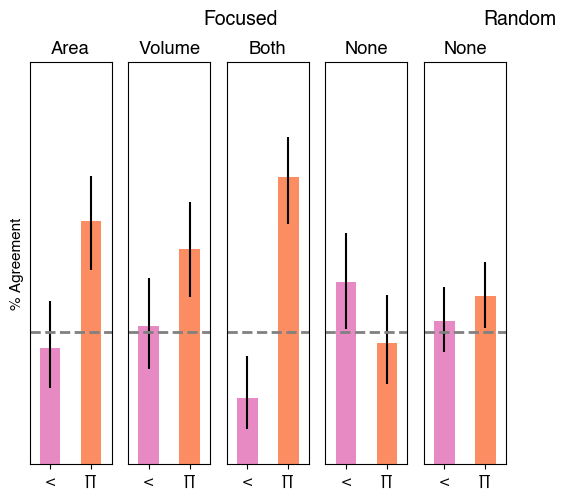

In [73]:
num = 5
fig, axes = plt.subplots(
    ncols=num, sharey=True, figsize=(1 + LLM_TEST_PLOT_WIDTH * num, 4.8)
)

plot_conditions_binomial(
    dfs=m_dfs2,
    selector=test,
    title="Focused",
    axes=axes[:-1],
    between=("scenario_rawls", "scenario_nbs"),
)


none_only = list(filter(lambda x: x.name == "None", m_random_dfs))

plot_conditions_binomial(
    dfs=none_only,
    selector=test,
    title="Random",
    axes=axes[-1],
    between=("scenario_rawls", "scenario_nbs"),
)

space_last_fig_add_titles(fig, axes)

save_fig(fig, f"mturk_test_condition_rawls_nash")

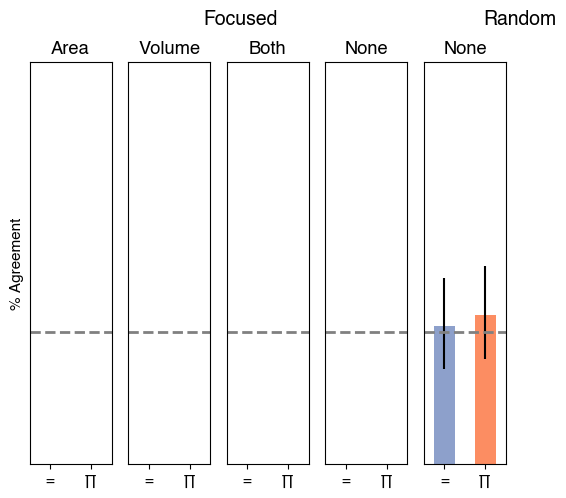

In [74]:
num = 5
fig, axes = plt.subplots(
    ncols=num, sharey=True, figsize=(1 + LLM_TEST_PLOT_WIDTH * num, 4.8)
)

plot_conditions_binomial(
    dfs=m_dfs2,
    selector=test,
    title="Focused",
    axes=axes[:-1],
    between=("scenario_fehr", "scenario_nbs"),
)


dfs = random_models_to_dfs_no_agg[model]
none_only = list(filter(lambda x: x.name == "None", m_random_dfs))

plot_conditions_binomial(
    dfs=none_only,
    selector=test,
    title="Random",
    axes=axes[-1],
    between=("scenario_fehr", "scenario_nbs"),
)

space_last_fig_add_titles(fig, axes)

save_fig(fig, f"mturk_test_condition_fehr_nash")

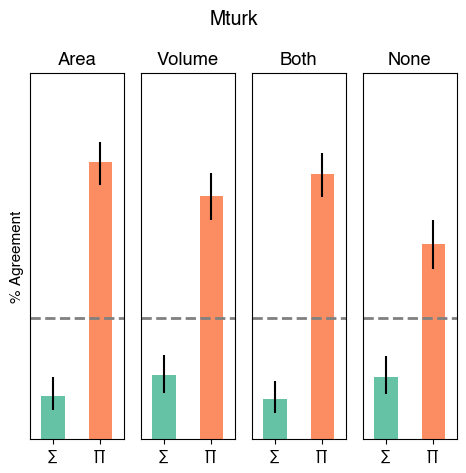

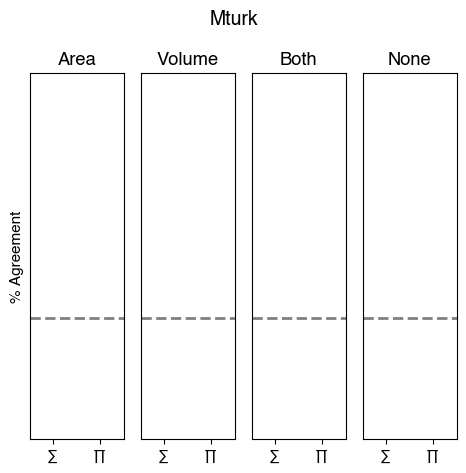

In [75]:
fig = plot_conditions_binomial(dfs=m_dfs2, selector=test, title="Mturk")
save_fig(fig, "mturk_test_condition")

fig = plot_conditions_binomial(dfs=m_dfs2, selector=test, title="Mturk", blank=True)
save_fig(fig, "mturk_test_condition_blank")

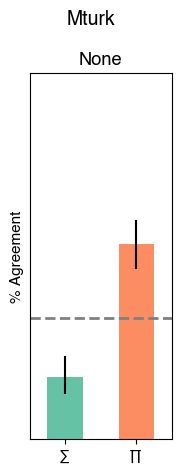

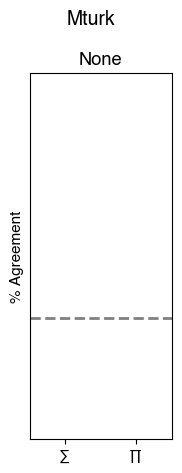

In [76]:
none_only = list(filter(lambda x: x.name == "None", m_dfs2))

fig = plot_conditions_binomial(dfs=none_only, selector=test, title="Mturk")
save_fig(fig, "mturk_test_condition_none")

fig = plot_conditions_binomial(dfs=none_only, selector=test, title="Mturk", blank=True)
save_fig(fig, "mturk_test_condition_none_blank")

<Axes: title={'center': 'Mturk % Correct Answer on Control -- filter control'}>

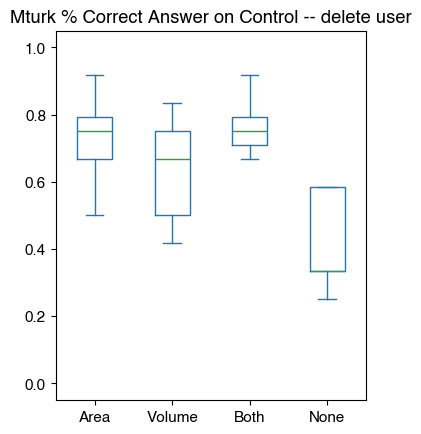

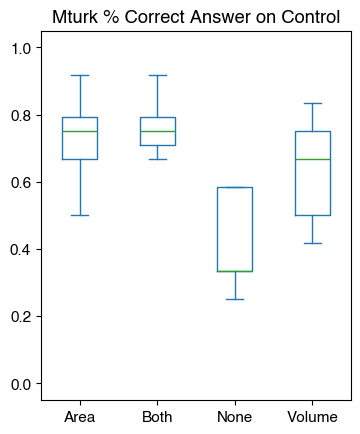

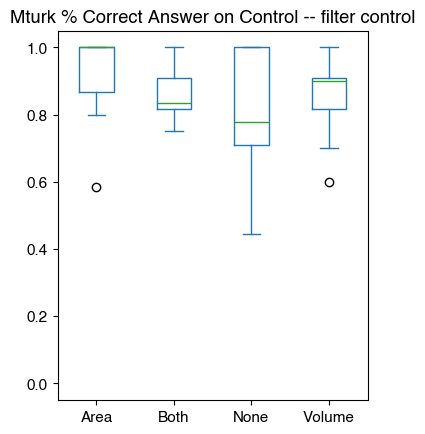

In [77]:
# Despite there being no difference in these, we will remove the entire user

result = []

for df in m_dfs_delete_user:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

pd.concat(result).plot.box(
    title="Mturk % Correct Answer on Control -- delete user",
    figsize=(4, 4.8),
    ylim=PERCENT_PLT_YLIM,
)

result = []

for df in m_dfs:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

pd.concat(result).plot.box(
    title="Mturk % Correct Answer on Control", figsize=(4, 4.8), ylim=PERCENT_PLT_YLIM
)

result = []

for df in m_dfs_filter_control:
    right_answer = (control(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

pd.concat(result).plot.box(
    title="Mturk % Correct Answer on Control -- filter control",
    figsize=(4, 4.8),
    ylim=PERCENT_PLT_YLIM,
)

<Axes: title={'center': 'Mturk % Correct Answer on Test (Utilitarian Sum answer)'}>

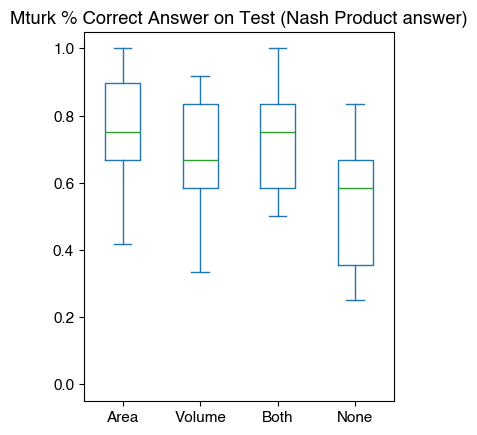

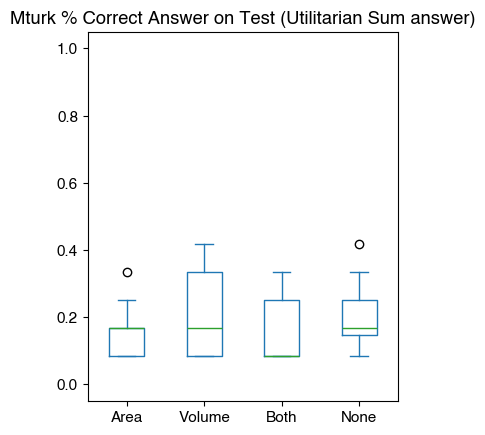

In [78]:
result = []

# TODO: combine these next two graphs and investigate why MEC % is so high

for df in m_dfs_delete_user:
    right_answer = (test(df)).apply(get_nbs_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

pd.concat(result).plot.box(
    title=f"Mturk % Correct Answer on Test ({nbs_long} answer)",
    figsize=(4, 4.8),
    ylim=PERCENT_PLT_YLIM,
)

result = []

for df in m_dfs_delete_user:
    right_answer = (test(df)).apply(get_mec_percent, axis=1)
    right_answer.name = df.name
    result.append(right_answer.to_frame())

pd.concat(result).plot.box(
    title=f"Mturk % Correct Answer on Test ({mec_long} answer)",
    figsize=(4, 4.8),
    ylim=PERCENT_PLT_YLIM,
)

## When there is disagreement which theory gets the most support?

## Stat tests and table construction

In [79]:
m_dfs_unaggregated = mturk_dfs(
    scenario, num_scenarios=num_scenarios, plot=False, aggregate_responses=False
)

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4


In [80]:
stat_tests_and_means_counts_control(
    sorted(m_dfs_unaggregated, key=lambda x: CONDITION_ORDER.index(x.name))
)

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
∑&∏ & 87 / 120*** & 77 / 120*** & 91 / 120*** & 50 / 120 \\
\bottomrule
\end{tabular}



In [81]:
stat_tests_and_means_counts_test(
    sorted(m_dfs_unaggregated, key=lambda x: CONDITION_ORDER.index(x.name))
)

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 165 / 216*** & 145 / 216*** & 158 / 216*** & 116 / 216*** \\
Utilitarian Sum & 26 / 216*** & 38 / 216*** & 24 / 216*** & 37 / 216*** \\
\bottomrule
\end{tabular}



In [82]:
dfs = llm_dfs(
    scenario, desired_model="gpt-4", qualification=False, aggregate_responses=False
)

In [83]:
# mturk
# llms

# TODO: change order to claude2, gpt-4, 3.5, davinci

for model in MODEL_NAMES_SHORT.keys():
    print(MODEL_NAMES_SHORT[model])
    dfs = sorted(
        llm_dfs(
            scenario,
            desired_model=model,
            qualification=False,
            aggregate_responses=False,
        ),
        key=lambda x: CONDITION_ORDER.index(x.name),
    )
    stat_tests_and_means_counts_test(dfs)
    stat_tests_and_means_counts_control(dfs)

gpt-4
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 60 / 72*** & 67 / 72*** & 65 / 72*** & 63 / 72*** \\
Utilitarian Sum & 0 / 72*** & 0 / 72*** & 0 / 72*** & 0 / 72*** \\
\bottomrule
\end{tabular}

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
∑&∏ & 18 / 40 & 26 / 40*** & 18 / 40 & 16 / 40 \\
\bottomrule
\end{tabular}

gpt-3.5
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 30 / 72 & 48 / 72*** & 43 / 72*** & 53 / 72*** \\
Utilitarian Sum & 18 / 72 & 7 / 72*** & 5 / 72*** & 1 / 72*** \\
\bottomrule
\end{tabular}

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
∑&∏ & 11 / 40 & 23 / 40** ($p=0.002$) & 17 / 40 & 12 / 40 \\
\bottomrule
\end{tabular}

davinci-002
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 20 / 72 & 20 / 72 & 20 / 72 & 20 / 72 \\
Utilitarian Sum & 28 / 72 & 28 / 72 & 28 / 72 & 28 / 72 \\


## random scenarios

In [84]:
m_dfs_unaggregated = mturk_dfs(
    random_scenario, num_scenarios=num_scenarios, plot=False, aggregate_responses=False
)

None: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.2 and std 5.2 and wage $29.1


In [85]:
stat_tests_and_means_counts_control(
    sorted(m_dfs_unaggregated, key=lambda x: CONDITION_ORDER.index(x.name))
)

\begin{tabular}{ll}
\toprule
 & None \\
\midrule
∑&∏ & 118 / 192*** \\
\bottomrule
\end{tabular}



In [86]:
stat_tests_and_means_counts_test(
    sorted(m_dfs_unaggregated, key=lambda x: CONDITION_ORDER.index(x.name))
)

\begin{tabular}{ll}
\toprule
 & None \\
\midrule
Nash Product & 90 / 216* ($p=0.011$) \\
Utilitarian Sum & 64 / 216 \\
\bottomrule
\end{tabular}



In [87]:
# 1) prepare your two dicts
dfs_by_model_random = {}
dfs_by_model_focused = {}
for short_name in MODEL_NAMES_SHORT:
    dfs_rand = llm_dfs(
        random_scenario,
        desired_model=short_name,
        qualification=False,
        aggregate_responses=False,
    )
    dfs_foc = llm_dfs(
        scenario,
        desired_model=short_name,
        qualification=False,
        aggregate_responses=False,
    )
    dfs_by_model_random[short_name] = dfs_rand
    dfs_by_model_focused[short_name] = dfs_foc

# 2) generate the combined table
generate_two_scenario_table(
    dfs_random=dfs_by_model_random,
    dfs_focused=dfs_by_model_focused,
    model_name_map=MODEL_NAMES_SHORT,
    condition_order=CONDITION_ORDER,
    prior=1 / 3,
)

\begin{tabular}{rrr||cccc}
\toprule
 &  &  & \texttt{Area} & \texttt{Volume} & \texttt{Both} & \texttt{None} \\
Model & Scenario &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{\texttt{claude-2}} & \multirow[t]{3}{*}{Focused} & $\Pi$ & 4 / 72*** & 2 / 72*** & 1 / 72*** & 0 / 72*** \\
 &  & $\Sigma$ & 63 / 72*** & 66 / 72*** & 69 / 72*** & 68 / 72*** \\
 &  & $\Sigma\&\Pi$ & 13 / 40 & 20 / 40* ($p=0.029$) & 11 / 40 & 9 / 40 \\
\cline{2-7}
 & \multirow[t]{3}{*}{Random} & $\Pi$ &  &  &  &  \\
 &  & $\Sigma$ &  &  &  &  \\
 &  & $\Sigma\&\Pi$ &  &  &  &  \\
\cline{1-7} \cline{2-7}
\multirow[t]{6}{*}{\texttt{claude-3}} & \multirow[t]{3}{*}{Focused} & $\Pi$ & 1 / 69*** & 0 / 72*** & 1 / 72*** & 0 / 72*** \\
 &  & $\Sigma$ & 59 / 69*** & 68 / 72*** & 66 / 72*** & 67 / 72*** \\
 &  & $\Sigma\&\Pi$ & 19 / 40 & 28 / 40*** & 17 / 40 & 18 / 40 \\
\cline{2-7}
 & \multirow[t]{3}{*}{Random} & $\Pi$ & 16 / 70 & 1 / 72*** & 6 / 71*** & 4 / 72*** \\
 &  & $\Sigma$ & 37 / 70*** & 62 / 72*** & 53 / 71*** & 

In [88]:
# mturk
# llms

# TODO: change order to claude2, gpt-4, 3.5, davinci

for model in MODEL_NAMES_SHORT.keys():
    print(MODEL_NAMES_SHORT[model])
    dfs = sorted(
        llm_dfs(
            random_scenario,
            desired_model=model,
            qualification=False,
            aggregate_responses=False,
        ),
        key=lambda x: CONDITION_ORDER.index(x.name),
    )
    stat_tests_and_means_counts_test(dfs)
    stat_tests_and_means_counts_control(dfs)

gpt-4
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 37 / 72** ($p=0.002$) & 64 / 72*** & 57 / 72*** & 51 / 72*** \\
Utilitarian Sum & 20 / 72 & 1 / 72*** & 6 / 72*** & 4 / 72*** \\
\bottomrule
\end{tabular}

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
∑&∏ & 41 / 64*** & 50 / 64*** & 47 / 64*** & 42 / 64*** \\
\bottomrule
\end{tabular}

gpt-3.5
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 29 / 72 & 46 / 72*** & 36 / 72** ($p=0.004$) & 34 / 72* ($p=0.017$) \\
Utilitarian Sum & 20 / 72 & 14 / 72* ($p=0.012$) & 20 / 72 & 10 / 72*** \\
\bottomrule
\end{tabular}

\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
∑&∏ & 26 / 64 & 40 / 64*** & 29 / 64* ($p=0.047$) & 15 / 64 \\
\bottomrule
\end{tabular}

davinci-002
\begin{tabular}{lllll}
\toprule
 & Area & Volume & Both & None \\
\midrule
Nash Product & 24 / 72 & 24 / 72 & 24 / 72 & 24 / 72 \\
Utilitar

## unused figures

KeyError: '∑'

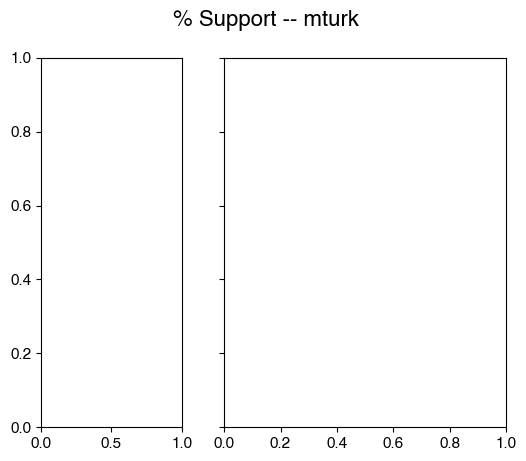

In [89]:
model_agree_stats_both_conditions(m_dfs, "mturk", percentage=True)
plt.savefig(f"figures/mturk_test.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# a graph of # and % in support of MEC, NBS, MFT for each of mturk and llm test

model_agree_stats_by_group(m_dfs, "Mturk Test", selector=test)

model_agree_stats_by_group(m_dfs, "Mturk Test", selector=test, percentage=True)

# This is interesting -- when you filter out those who did not get the control cases, the number in support
# of MEC increases... but could also just be due to having a smaller smaple

model_agree_stats_by_group(
    m_dfs_filter_control, "Mturk Test -- filter control", selector=test
)


# a graph of # and % in support of MEC, NBS, MFT for each of mturk and llm test

model_agree_stats_by_group(m_dfs, "Mturk Control", selector=control)

model_agree_stats_by_group(m_dfs, "Mturk Control", selector=control, percentage=True)

model_agree_stats_by_group(
    m_dfs_filter_control, "Mturk Control -- filter control", selector=control
)

In [ ]:
# NB: None is no longer included as an option when analyzing `model_agree_stats`
# this does reduce the total number of items analyzed

# TODO: Why is the mass split between MEC and NBS on the control case? Shouldn't it be close to 1 as with
# the humans

# model_agree_stats_by_group(llm_dfs_no_chart, "test no chart", selector=test, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_no_chart, "control no chart", selector=control, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_area_chart, "test area", selector=test, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_area_chart, "control area", selector=control, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_volume_chart, "test volume", selector=test, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_volume_chart, "control volume", selector=control, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_both_chart, "test both charts", selector=test, order=order, percentage=True)

# model_agree_stats_by_group(llm_dfs_both_chart, "control both charts", selector=control, order=order, percentage=True)

In [ ]:
# TODO: don't have zero shot data for some reason?
# Need to re run with it

In [ ]:
def model_agree_stats_by_condition(group, name, selector=None, percentage=True):
    results = {"Area": [], "Both": [], "Volume": [], "None": []}

    for df in group:
        df_name = df.name
        if "qualification=True" in df_name:
            continue
        if "show-charts=False" in df_name:
            df_name = "None"
        if selector:
            df = selector(df)
        agree = model_agree_stats(df, percentage)
        for key in results.keys():
            if key.lower() in df_name.lower():
                results[key].append(agree)

    for key in results.keys():
        results[key] = (
            pd.concat(results[key], axis=1).div(len(results[key])).sum(axis=1)
        )
        results[key].name = key

    prefix = "#"
    ylim = None
    if percentage:
        prefix = "%"
        ylim = (0, 1)
    pd.concat(results.values(), axis=1).plot.bar(
        title=f"{prefix} Support -- {name}", ylim=ylim
    )

In [ ]:
dfs = llm_dfs(scenario, desired_model="gpt-4")
model_agree_stats_by_condition(dfs, "gpt-4 control", selector=control, percentage=False)
model_agree_stats_by_condition(dfs, "gpt-4 test", selector=test, percentage=False)

# model_agree_stats_by_condition(dfs, "gpt-4 fair nbs control", selector=fair_nbs_control, percentage=False)
# model_agree_stats_by_condition(dfs, "gpt-4 fair nbs test", selector=fair_nbs_test, percentage=False)

# model_agree_stats_by_condition(dfs, "gpt-4 fair mec control", selector=fair_mec_control, percentage=False)
# model_agree_stats_by_condition(dfs, "gpt-4 fair mec test", selector=fair_mec_test, percentage=False)

# model_agree_stats_by_condition(dfs, "gpt-4 all control", selector=fair_mec_nbs_control, percentage=False)
# model_agree_stats_by_condition(dfs, "gpt-4 all test", selector=fair_mec_nbs_test, percentage=False)

In [ ]:
# Drilling down here on when not using `fair_dominated` but in a control condition (NBS == MEC) and
# FAIR != NBS / MEC

# TODO: which of these figures is the best demonstration of this?

# d = (not_null_ties_fair(not_null_ties(control(dfs[0]))))
# print(len(d))
# print(len(d[d['response'] == d['scenario_fair']]))

# sel = d[(d['response'] != d['scenario_nbs']) & (d['response'] != d['scenario_fair'])]
# row = sel.iloc[2]
# print(len(sel))
# print(row)
# gs = pm.decode_gameState(row['scenario_json'])
# pm.run_fair_dominated(gs)
# print(gs)

In [ ]:
for model_name in MODEL_NAMES_SHORT.keys():
    dfs = llm_dfs(scenario, desired_model=model_name, qualification=False)
    model_agree_stats_both_conditions(dfs, model_name, percentage=False)

for model_name in MODEL_NAMES_SHORT.keys():
    dfs = llm_dfs(scenario, desired_model=model_name, qualification=False)
    model_agree_stats_both_conditions(dfs, model_name, percentage=True)

In [ ]:
for model_name in MODEL_NAMES_SHORT.keys():
    dfs = llm_dfs(scenario, desired_model=model_name, qualification=False)
    model_agree_stats_both_conditions(dfs, model_name, percentage=True)

    plt.savefig(f"figures/{model_name}_test.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
# TODO: shoudl use the constant list instead of calling each model

for model_name in MODEL_NAMES_SHORT.keys():
    dfs = llm_dfs(scenario, desired_model=model_name)
    model_agree_stats_by_condition(
        dfs, model_name + " Control", selector=control, percentage=True
    )
    #     model_agree_stats_by_condition(dfs, model_name + " Fair Test", selector=fair_test_mec_nbs_control, percentage=True)
    model_agree_stats_by_condition(
        dfs, model_name + " Test", selector=test, percentage=True
    )


# model_agree_stats_by_condition('gpt-3.5-turbo-16k', scenario)

# model_agree_stats_by_condition('claude-2', scenario)
# model_agree_stats_by_condition('davinci-002', scenario)

In [ ]:
# I think these findings above indicate that the showing of charts to the models actually does not
# do anything

# Grandual, individual level comparisons from before

#### mturk stats

In [ ]:
mturk_df = mturk_dfs(scenario, num_scenarios, desired_condition=mturk_condition)[0]

In [ ]:
llm_df = llm_dfs(scenario, desired_condition=llm_condition, desired_model=model)[0]

In [ ]:
# This is how to drill down into those who fail the attention checks...
# TODO: could go get more data for these?
# mturk_df_no_attn[mturk_df_no_attn['attention-answer'] != mturk_df_no_attn['attention-response']]

# A1VFD3NK30LXPO, A1TJ0CYOQ7J676 definitely look like they are spamming

## Breaking up "controls"

In [ ]:
# TODO: should consider only looking at the exact intersection between the two
# should be guaranteed by default in new approach
intersection_df = get_intersection(llm_df, mturk_df)

## (control) How much support did the right answer get? The max answer?

In [ ]:
# Add the answer ranks to the dfs

mturk_df_dist = get_response_dist(mturk_df, ["scenario_hash"])
mturk_df_dist = add_mft(mturk_df_dist)

mturk_answer_rank = mturk_df_dist.apply(get_mec_rank, axis=1)
mturk_answer_rank.name = f"{mec_short} rank"
mturk_df_dist = mturk_df_dist.merge(
    mturk_answer_rank, left_index=True, right_index=True
)

llm_df_dist = get_response_dist(llm_df, ["scenario_hash"])
llm_df_dist = add_mft(llm_df_dist)

llm_answer_rank = llm_df_dist.apply(get_mec_rank, axis=1)
llm_answer_rank.name = f"{mec_short} rank"
llm_df_dist = llm_df_dist.merge(llm_answer_rank, left_index=True, right_index=True)

### Mturk 

In [ ]:
### Are respondents as uncertain when the theories are uncertain? (When the theories both tie?)

In [ ]:
# TODO: need to drill down into this graph to see what is going on
# This just means that there is not unanimity, that the max answer
# usually only gets 55%. Nonetheless, the "right" (control) answer still tends to be chosen
plot_answer_distribution(mturk_df_dist)

#### The proportion that got the answer right vs not

In [ ]:
control(mturk_df_dist).groupby(["scenario_hash"]).apply(
    top_in_answers
).value_counts().plot.bar()

#### When they do not get the correct answer what is the distribution of votes like?

In [ ]:
# we do want this to look like exponentially decreasing
plot_rank_answer_distribution(mturk_df_dist)

### If the right answer is not top ranked, how well is it explained (what percent) by other theories?

In [ ]:
# Broader question: when people are not doing what we thought they would do, what are they doing?
# Is there a different hypothesis to explain the minority opinions in the data?

In [ ]:
dist = control(mturk_df_dist)
mturk_not_top_answer = dist[dist[f"{mec_short} rank"] != 1]

dist = control(llm_df_dist)
llm_not_top_answer = dist[dist[f"{mec_short} rank"] != 1]

mturk_models = model_agree_stats(mturk_not_top_answer, percentage=True)
mturk_models.name = "mturk"
llm_models = model_agree_stats(llm_not_top_answer, percentage=True)
llm_models.name = "llm"

pd.concat([mturk_models.to_frame(), llm_models.to_frame()], axis=1).plot.bar()

In [ ]:
# is there significant disagreement? e.g. 1/3 1/3 1/3
mturk_not_top_answer.apply(get_answer_percent, axis=1)

### LLM

In [ ]:
# this is weird... what explains why the models are so across the board?
# MFT (as in the graph above)

plot_answer_distribution(llm_df_dist)

In [ ]:
plot_rank_answer_distribution(llm_df_dist)

In [ ]:
## Drilling down on the question above
# rank = 3
# dist = control(mturk_df_dist)
# max_ans = dist[dist['mec rank'] == rank].apply(get_answer_percent, axis=1)
# max_ans.name = f'max r. {rank}'

# mec_ans = dist[dist['mec rank'] == rank].apply(get_mec_percent, axis=1)
# mec_ans.name = f'mec r. {rank}'

## (control) How well did the right answer rank? Was it the first, second, third, choice?

In [ ]:
mturk_answer_rank = control(mturk_df_dist)[f"{mec_short} rank"].value_counts()
mturk_answer_rank.name = "mturk"

llm_answer_rank = control(llm_df_dist)[f"{mec_short} rank"].value_counts()
llm_answer_rank.name = "llm"

pd.concat([mturk_answer_rank, llm_answer_rank], axis=1).plot.bar()

### Walking through an example disagreement b/w LLM + MEC/NBS

In [ ]:
llm_df_control = control(llm_df)
example_disagree = llm_df_control[
    llm_df_control["response"] != llm_df_control["scenario_nbs"]
]

# My summary of the mistakes the model makes:
# - confuses itself in terms of what is best (makes inaccurate summarizing claims), xx
# - pareto-suboptimal fairness: considering the need to balance the desires of all groups, xxxx
#    (Doens't want to benefit any one group too much)

# TODO: still need to make the model to fit to this

# compare_llm_and_scenario(example_disagree.iloc[0])

## (Test) Which model best explains the responses?

In [ ]:
# a graph of # and % in support of MEC, NBS, MFT for each of mturk and llm test
mturk_models = model_agree_stats(test(mturk_df_dist))
mturk_models.name = "mturk"
llm_models = model_agree_stats(test(llm_df_dist))
llm_models.name = "llm"

pd.concat([mturk_models.to_frame(), llm_models.to_frame()], axis=1).plot.bar()

### comparing two mturk dfs... use this for future analysis as how to compare

In [ ]:
# this is for the question Sydney was asking about

# I don't think there is any meaningful
# difference expect for the fact that the participants in the volume group are more better at getting the
# 'right' answer which seems to say that they support NBS. but how to measure this?

m1 = when_not_both_nan(
    mturk_.explode_df(
        pd.read_csv("data/results/mturk/pilot/health_pilot_5.csv"), num_scenarios
    )
)
m2 = when_not_both_nan(
    mturk_explode_df(
        pd.read_csv("data/results/mturk/pilot/health_pilot_volume_1.csv"), num_scenarios
    )
)

m1 = get_intersection(m1, m2)
m2 = get_intersection(m2, m1)

plot_answer_distribution(get_response_dist(m1, ["scenario_hash"]))
plot_answer_distribution(get_response_dist(m2, ["scenario_hash"]))


one = model_agree_stats(test(m1))
one.name = "area shown"
two = model_agree_stats(test(m2))
two.name = "volume shown"

pd.concat([one.to_frame(), two.to_frame()], axis=1).plot.bar()

In [ ]:
# TODO: need a more principled way to compute `model_agree_stats` think on that first, then see if
# there is a way to work this weird intersection problem

In [ ]:
tm1 = test(m1)
tm2 = test(m2)
len(tm1[tm1["scenario_mec"] == tm1["response"]])

In [ ]:
tm2[(tm2["scenario_mec"] == tm2["response"]) & (tm1["scenario_mec"] != tm1["response"])]

In [ ]:
# merge the two
merged = test(m1).merge(test(m2), on=["scenario_hash"])
merged[
    (merged["response_x"] == merged["scenario_mec_x"])
    & (merged["response_y"] != merged["scenario_mec_y"])
]
# tm1[(tm1['response'] != tm1['scenario_mec']) & (tm2['response'] == tm2['scenario_mec'])]

In [ ]:
merged[
    (merged["response_x"] != merged["scenario_mec_x"])
    & (merged["response_y"] == merged["scenario_mec_y"])
]

In [ ]:
merged[
    (merged["response_x"] != merged["response_y"])
    & (merged["response_y"] != merged["scenario_mec_y"])
]

In [ ]:
# What is happening in the MEC cases? What is the agreement like?
d = test(mturk_df_dist)


d[d["scenario_mec"] == d["response"]].iloc[2]

In [ ]:
# Open the above game state in `mturk/test_graph.html` to see what it looks like.

## (test) Was the top choice one of the MEC, NBS answers?

In [ ]:
# We might have expected that in the non clear cut cases people are choosing
# randomly, but it doesn't look like that! Then the next question is whether they
# are choosing randomly between MEC and NBS

# These graphs try to show if there a difference in the degree of support the max answer gets between
# the control and test cases

# TODO: calculate the stats, default should be 33% by chance

In [ ]:
test_ans = (
    test(mturk_df).groupby(["scenario_hash"]).apply(top_in_answers).value_counts()
)
test_ans.name = "mec != nbs"

control_ans = (
    control(mturk_df).groupby(["scenario_hash"]).apply(top_in_answers).value_counts()
)
control_ans.name = "mec == nbs"

pd.concat([test_ans.to_frame(), control_ans.to_frame()], axis=1).plot.bar()

### LLM

In [ ]:
test_ans = test(llm_df).groupby(["scenario_hash"]).apply(top_in_answers).value_counts()
test_ans.name = "mec != nbs"

control_ans = (
    control(llm_df).groupby(["scenario_hash"]).apply(top_in_answers).value_counts()
)
control_ans.name = "mec == nbs"

pd.concat([test_ans.to_frame(), control_ans.to_frame()], axis=1).plot.bar()

## When the LLM gives no answer

In [ ]:
llm_df_raw = 
no_answer(llm_df_raw)

## Getting rid of cases when only one theory ties (old)

In [ ]:
# TODO: do we actually want to get rid of these data points?
# Removing for now; I believe this is handled by the changes to scenario generation
print(f"llm one ties {len(llm_df_raw) - len(when_not_both_nan(llm_df_raw))}")
print(
    f"mturk one ties {len(mturk_df_no_attn) - len(when_not_both_nan(mturk_df_no_attn))}"
)

In [ ]:
llm_df_raw = when_not_both_nan(llm_df_raw)
mturk_df_no_attn = when_not_both_nan(mturk_df_no_attn)

### Comparing with MFT (not meaningful b/c current split is equal)

In [ ]:
if "scenario_mft" not in mturk_df.columns:
    mturk_df = add_mft(mturk_df)
if "scenario_mft" not in llm_df.columns:
    llm_df = add_mft(llm_df)

mturk_df_all_agree = mturk_df[
    (mturk_df["scenario_nbs"] == mturk_df["scenario_mec"])
    & (mturk_df["scenario_mec"] == mturk_df["scenario_mft"])
]
print(f"mturk df all agree #: {len(mturk_df_all_agree)}")

mturk_df_all_disagree = mturk_df[
    (mturk_df["scenario_nbs"] != mturk_df["scenario_mec"])
    & (mturk_df["scenario_mec"] != mturk_df["scenario_mft"])
    & (mturk_df["scenario_nbs"] != mturk_df["scenario_mft"])
]
print(f"mturk df all disagree #: {len(mturk_df_all_disagree)}")

print()

llm_df_all_agree = llm_df[
    (llm_df["scenario_nbs"] == llm_df["scenario_mec"])
    & (llm_df["scenario_mec"] == llm_df["scenario_mft"])
]
print(f"llm df all agree #: {len(llm_df_all_agree)}")
llm_df_all_disagree = llm_df[
    (llm_df["scenario_nbs"] != llm_df["scenario_mec"])
    & (llm_df["scenario_mec"] != llm_df["scenario_mft"])
    & (llm_df["scenario_nbs"] != llm_df["scenario_mft"])
]
print(f"llm df all disagree #: {len(llm_df_all_disagree)}")

## How different is the LLM under different temperature settings? (old)